In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
def get_kmer_counts(sequence, k=6):
    """Count all k-mers in a sequence."""
    kmers = Counter()
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if 'N' not in kmer:  # Skip k-mers with N
            kmers[kmer] += 1
    return kmers

def get_reverse_complement(kmer):
    """Get reverse complement of a k-mer."""
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement.get(base, base) for base in reversed(kmer))

def normalize_kmer(kmer):
    """Return canonical k-mer (lexicographically smaller of kmer and its RC)."""
    rc = get_reverse_complement(kmer)
    return min(kmer, rc)

In [3]:
# Analyze multiple k-mer sizes
k_sizes = [2, 3, 4, 5, 6, 7, 8]

In [4]:
TARGET_C = -0.5

In [5]:
df0 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold0_with_positions_steps_results.tsv", sep="\t")

In [6]:
df1 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold1_with_positions_steps_results.tsv", sep="\t")

In [7]:
df2 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold2_with_positions_steps_results.tsv", sep="\t")

In [8]:
df3 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold3_with_positions_steps_results.tsv", sep="\t")

In [9]:
df4 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold4_with_positions_steps_results.tsv", sep="\t")

In [10]:
df5 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold5_with_positions_steps_results.tsv", sep="\t")

In [11]:
df6 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold6_with_positions_steps_results.tsv", sep="\t")

In [12]:
df7 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/fold7_with_positions_steps_results.tsv", sep="\t")

In [13]:
df = pd.concat([df0, df1, df2,
                df3, df4, df5,
                df6, df7], ignore_index=True)

In [14]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [15]:
# selecting only sequences with a measurable contact enrichment
df = df[df['URQ_diff'] > 0.0]


In [ ]:
len(df)

In [16]:
import torch

In [17]:
def tensor_to_sequence(seq_tensor):
    """Convert one-hot encoded tensor to DNA sequence string."""
    if seq_tensor.dim() == 3:
        seq_tensor = seq_tensor.squeeze(0)  # [4, L]
    
    nucleotides = ['A', 'C', 'G', 'T']
    indices = torch.argmax(seq_tensor, dim=0)
    sequence = ''.join([nucleotides[i] for i in indices])
    return sequence

In [18]:
results_by_k = {}

for k in k_sizes:
    print(f"\n{'='*80}")
    print(f"Analyzing {k}-mers...")
    print(f"{'='*80}")
    
    # Collect k-mers from all sequences
    orig_kmers_all = Counter()
    edited_kmers_all = Counter()
    
    for idx, row in df.iterrows():
        chrom = row["chrom"]
        cstart = row["centered_start"]
        cend = row["centered_end"]
        fold = row["fold"]
        
        # Load sequences
        orig_path = f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/ohe_X/{fold}/{chrom}_{cstart}_{cend}_X.pt"
        X = torch.load(orig_path, map_location='cpu')
        edit_start = (256 + 64) * 2048
        edit_end = edit_start + 2048
        orig_slice = X[:, :, edit_start:edit_end]
        orig_seq = tensor_to_sequence(orig_slice)
        
        edited_path = f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/{fold}/{chrom}_{cstart}_{cend}_slice.pt"
        edited_slice = torch.load(edited_path, map_location='cpu')
        edited_seq = tensor_to_sequence(edited_slice)
        
        # Count k-mers (combine k-mer and its RC)
        orig_kmers = get_kmer_counts(orig_seq, k=k)
        edited_kmers = get_kmer_counts(edited_seq, k=k)
        
        # Normalize by combining with reverse complement
        for kmer, count in orig_kmers.items():
            canonical = normalize_kmer(kmer)
            orig_kmers_all[canonical] += count
        
        for kmer, count in edited_kmers.items():
            canonical = normalize_kmer(kmer)
            edited_kmers_all[canonical] += count
    
    # Calculate enrichment
    total_orig = sum(orig_kmers_all.values())
    total_edited = sum(edited_kmers_all.values())
    
    enrichment_data = []
    
    for kmer in set(orig_kmers_all.keys()) | set(edited_kmers_all.keys()):
        orig_count = orig_kmers_all[kmer]
        edited_count = edited_kmers_all[kmer]
        
        # Skip very rare k-mers
        if orig_count < 5 and edited_count < 5:
            continue
        
        # Calculate frequencies
        orig_freq = orig_count / total_orig if total_orig > 0 else 0
        edited_freq = edited_count / total_edited if total_edited > 0 else 0
        
        # Calculate fold change (with pseudocount)
        fold_change = (edited_count + 1) / (orig_count + 1)
        log2_fc = np.log2(fold_change)
        
        # Calculate GC content
        gc_content = (kmer.count('G') + kmer.count('C')) / len(kmer)
        
        # Chi-square test for significance
        contingency = np.array([
            [edited_count, total_edited - edited_count],
            [orig_count, total_orig - orig_count]
        ])
        
        try:
            chi2, p_value = stats.chi2_contingency(contingency)[:2]
        except:
            p_value = 1.0
        
        enrichment_data.append({
            'kmer': kmer,
            'k': k,
            'orig_count': orig_count,
            'edited_count': edited_count,
            'orig_freq': orig_freq,
            'edited_freq': edited_freq,
            'fold_change': fold_change,
            'log2_fc': log2_fc,
            'gc_content': gc_content,
            'p_value': p_value
        })
    
    enrichment_df = pd.DataFrame(enrichment_data)
    
    # Sort by fold change
    enrichment_df = enrichment_df.sort_values('fold_change', ascending=False)
    
    results_by_k[k] = enrichment_df
    
    # Print top enriched and depleted
    print(f"\nTop 20 most ENRICHED {k}-mers in edited slices:")
    print(enrichment_df.head(20)[['kmer', 'fold_change', 'gc_content', 'orig_count', 'edited_count', 'p_value']].to_string())
    
    print(f"\nTop 20 most DEPLETED {k}-mers in edited slices:")
    print(enrichment_df.tail(20)[['kmer', 'fold_change', 'gc_content', 'orig_count', 'edited_count', 'p_value']].to_string())


Analyzing 2-mers...

Top 20 most ENRICHED 2-mers in edited slices:
  kmer  fold_change  gc_content  orig_count  edited_count        p_value
4   CG     3.127792         1.0        8372         26188   0.000000e+00
6   CC     1.456742         1.0       71615        104325   0.000000e+00
8   GC     1.301613         1.0       30369         39529  1.990603e-276
7   AT     1.034598         0.0       53355         55201   5.673135e-09
1   AC     1.003090         0.5       77020         77258   5.228392e-01
0   TA     0.957187         0.0       46083         44110   1.164413e-11
9   CA     0.956809         0.5      106270        101680   1.296558e-27
3   GA     0.901932         0.5       88060         79424  9.955300e-112
5   AA     0.801802         0.0      128436        102980   0.000000e+00
2   AG     0.794555         0.5      102776         81661   0.000000e+00

Top 20 most DEPLETED 2-mers in edited slices:
  kmer  fold_change  gc_content  orig_count  edited_count        p_value
4   CG   

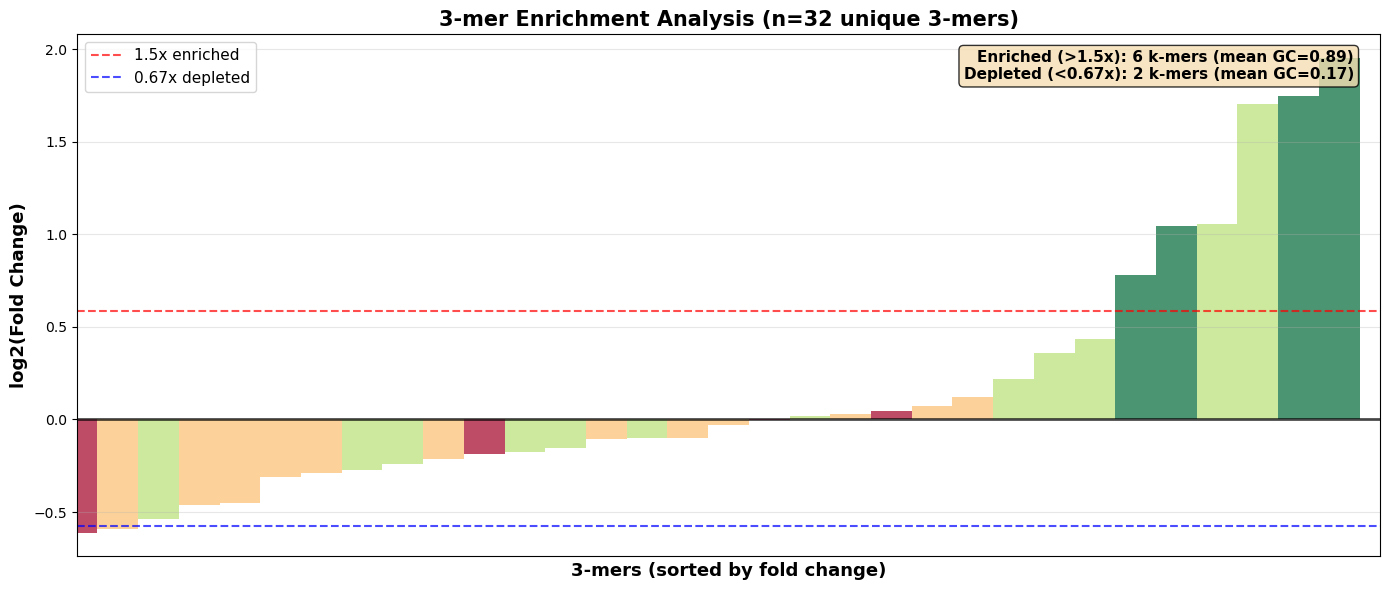

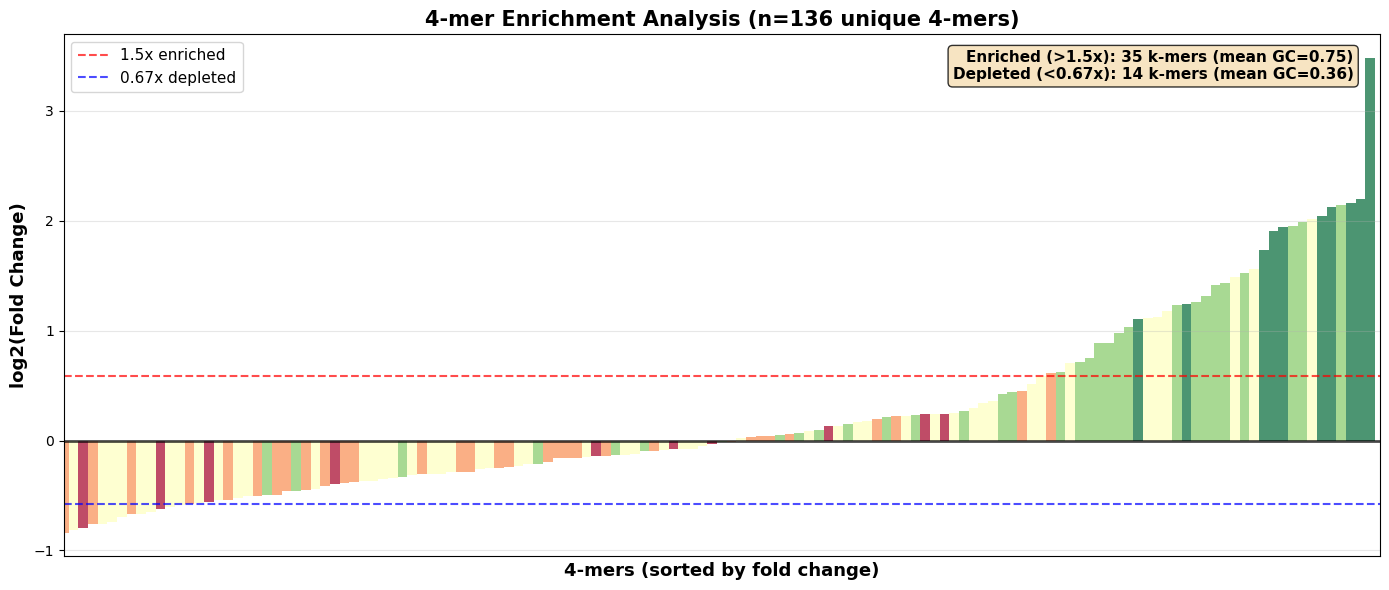

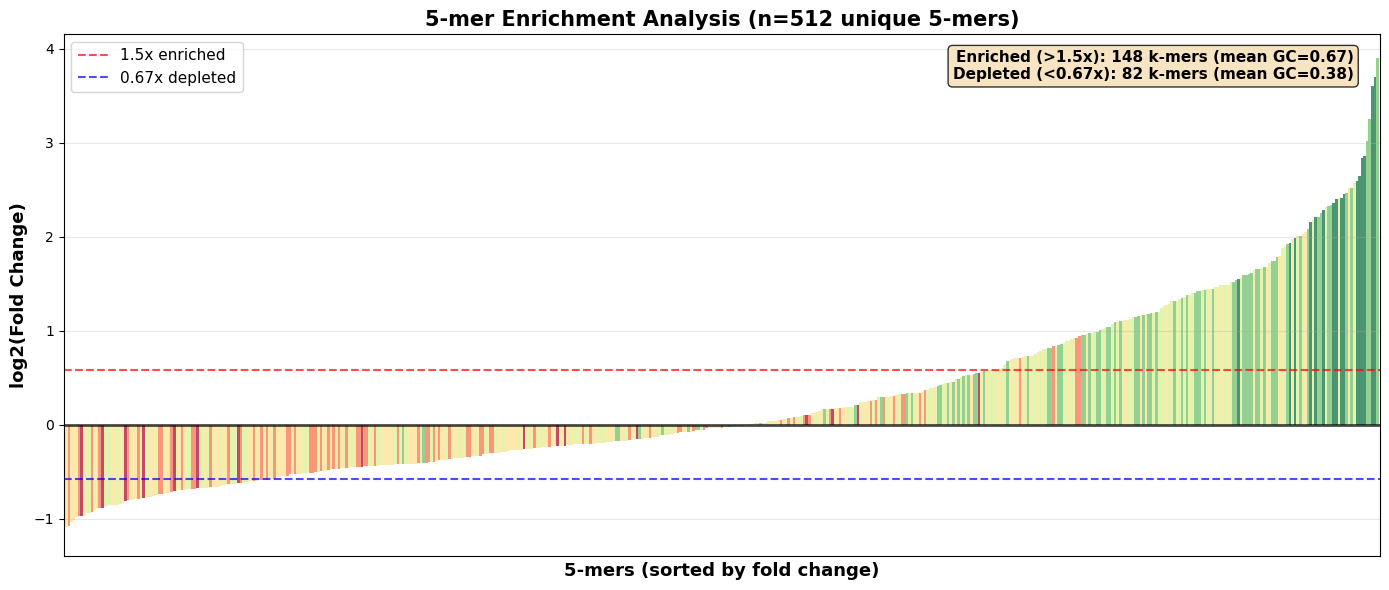

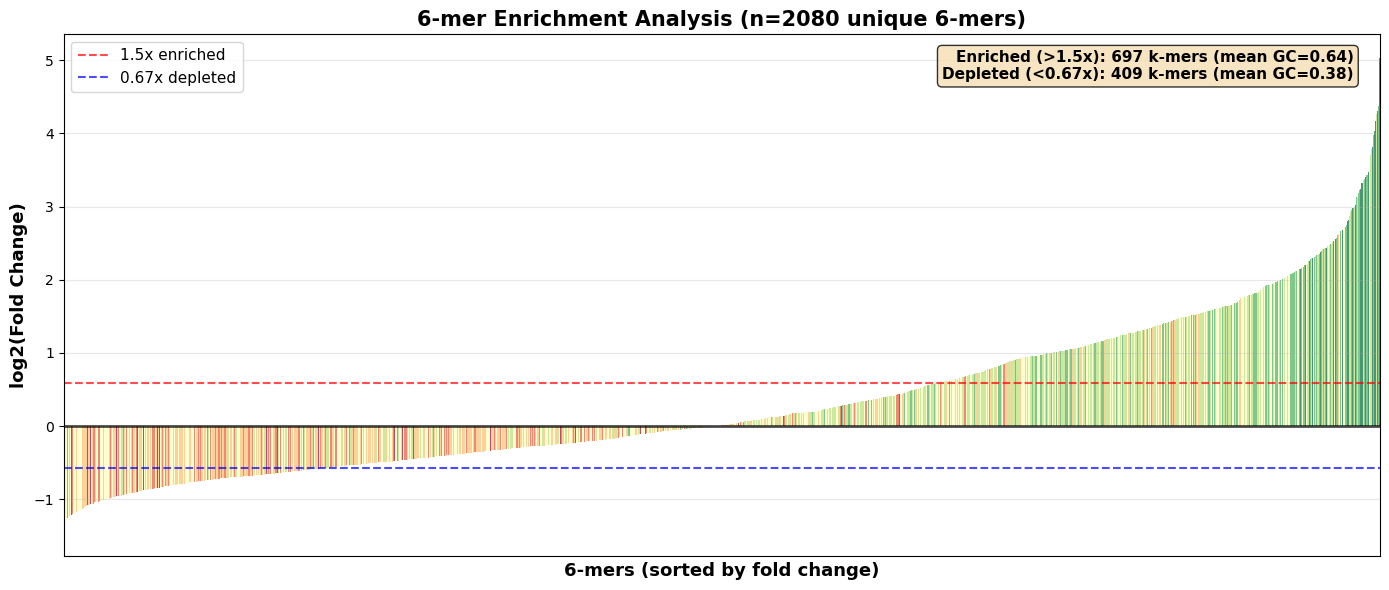

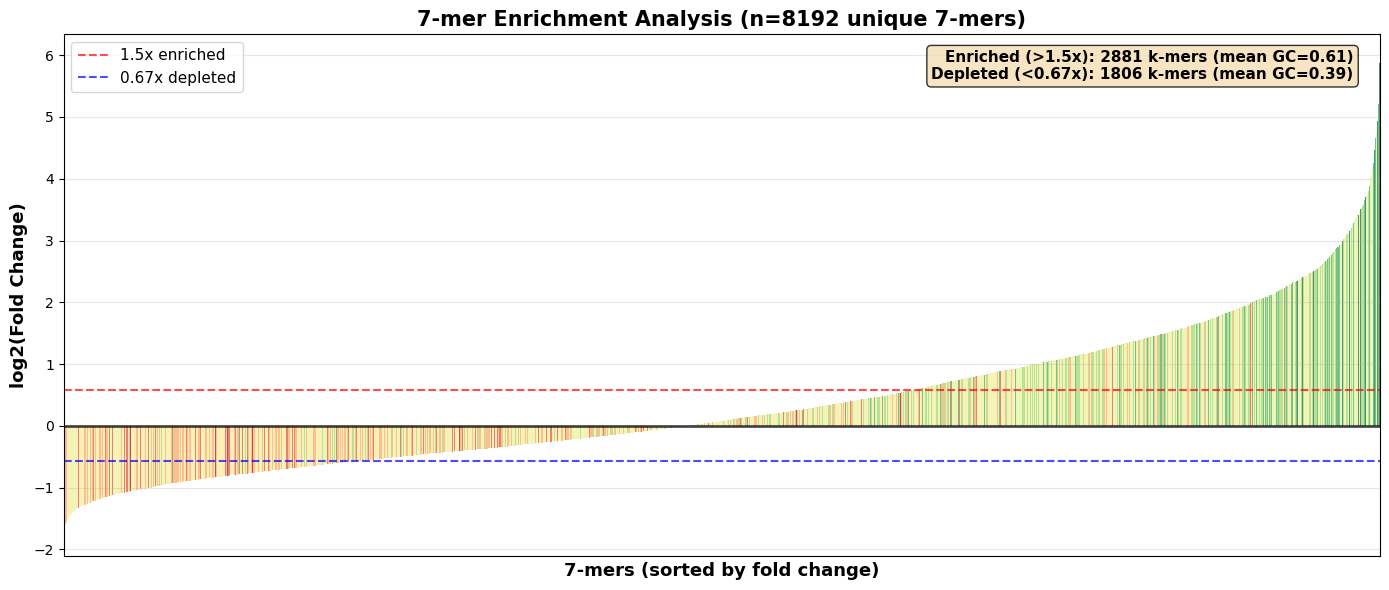

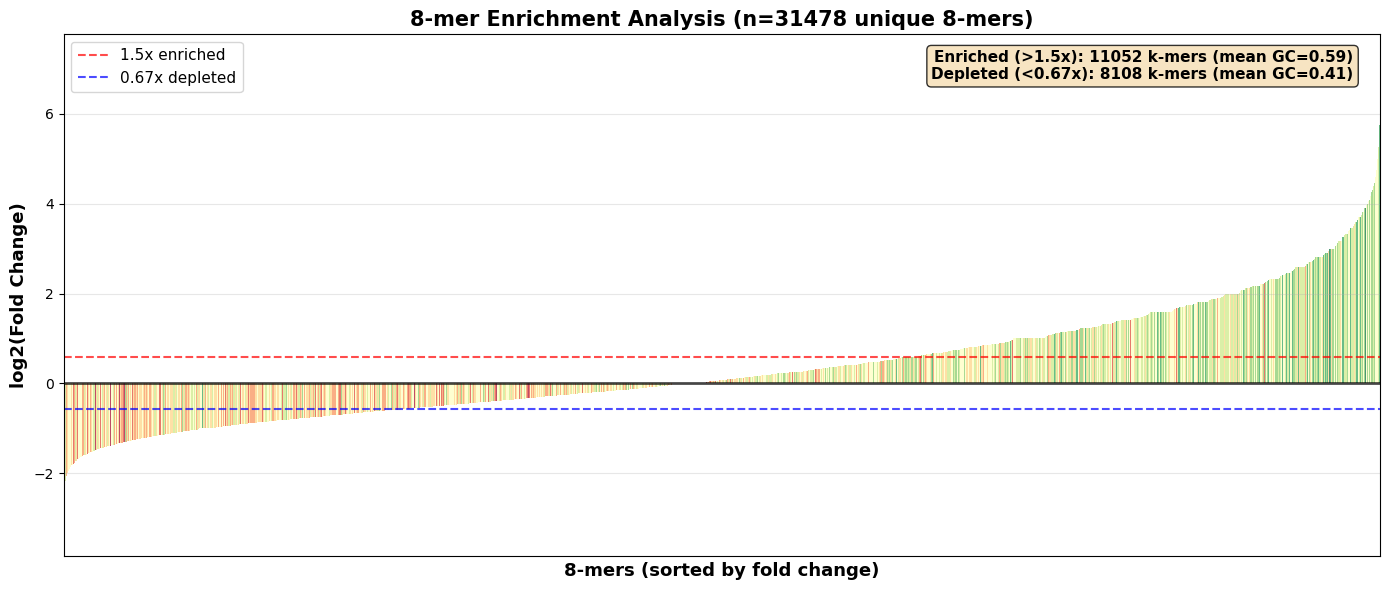

In [19]:
# ============= SEPARATE PLOT FOR EACH K =============

for k in [3, 4, 5, 6, 7, 8]:
    df_k = results_by_k[k]
    
    # Sort by log2 fold change
    df_k_sorted = df_k.sort_values('log2_fc')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Create x positions
    x_pos = np.arange(len(df_k_sorted))
    
    # Color by GC content
    colors = plt.cm.RdYlGn(df_k_sorted['gc_content'])
    
    # Bar plot
    bars = ax.bar(x_pos, df_k_sorted['log2_fc'], color=colors, alpha=0.7, width=1.0)
    
    # Add horizontal line at 0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
    
    # Mark enrichment thresholds
    ax.axhline(y=np.log2(1.5), color='red', linestyle='--', linewidth=1.5, 
               alpha=0.7, label='1.5x enriched')
    ax.axhline(y=np.log2(0.67), color='blue', linestyle='--', linewidth=1.5, 
               alpha=0.7, label='0.67x depleted')
    
    ax.set_xlabel(f'{k}-mers (sorted by fold change)', fontsize=13, fontweight='bold')
    ax.set_ylabel('log2(Fold Change)', fontsize=13, fontweight='bold')
    ax.set_title(f'{k}-mer Enrichment Analysis (n={len(df_k_sorted)} unique {k}-mers)', 
                 fontsize=15, fontweight='bold')
    ax.set_xlim(0, len(df_k_sorted))
    
    # Remove x-ticks (too many to show)
    ax.set_xticks([])
    
    # Add statistics box
    n_enriched = (df_k_sorted['fold_change'] > 1.5).sum()
    n_depleted = (df_k_sorted['fold_change'] < 0.67).sum()
    mean_gc_enriched = df_k_sorted[df_k_sorted['fold_change'] > 1.5]['gc_content'].mean()
    mean_gc_depleted = df_k_sorted[df_k_sorted['fold_change'] < 0.67]['gc_content'].mean()
    
    textstr = (f'Enriched (>1.5x): {n_enriched} k-mers (mean GC={mean_gc_enriched:.2f})\n'
               f'Depleted (<0.67x): {n_depleted} k-mers (mean GC={mean_gc_depleted:.2f})')
    
    ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontweight='bold')
    
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'/scratch1/smaruj/suppressing_CTCFs/kmer_{k}mer_log2fc.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # print(f"✓ Saved {k}-mer plot")

# print("\n✓ All individual plots saved!")

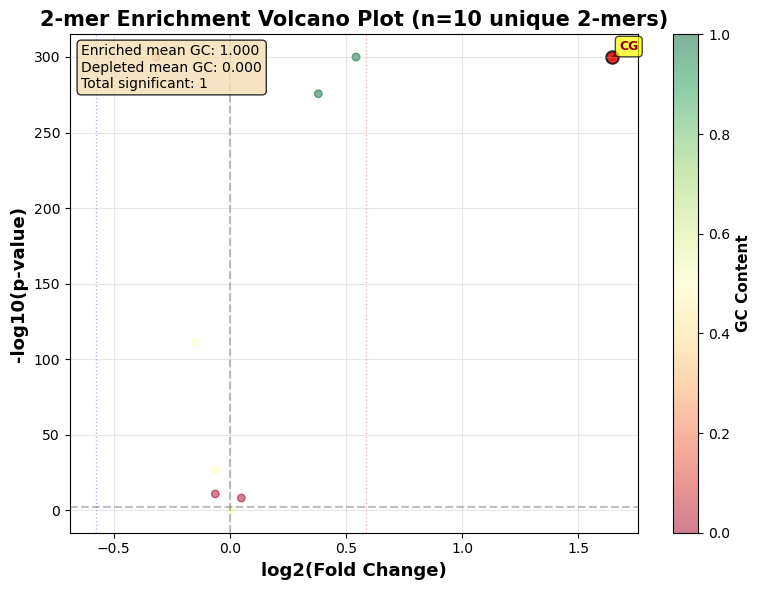

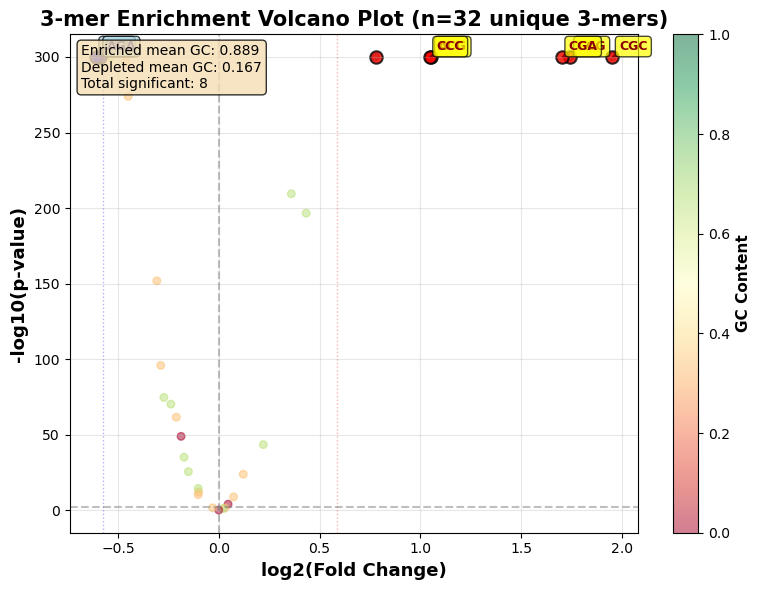

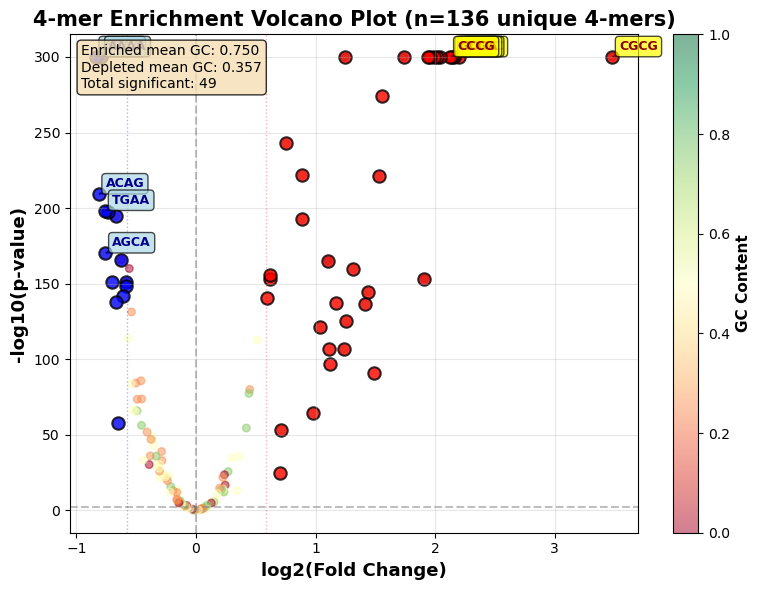

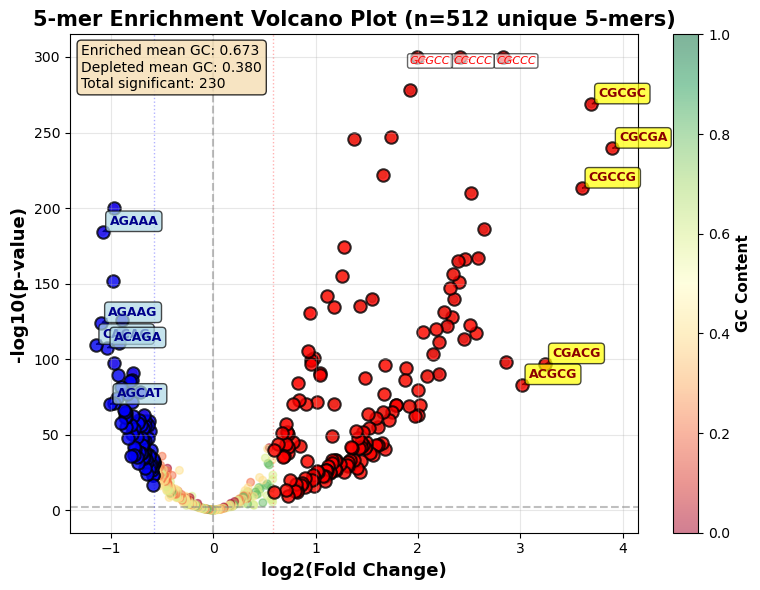

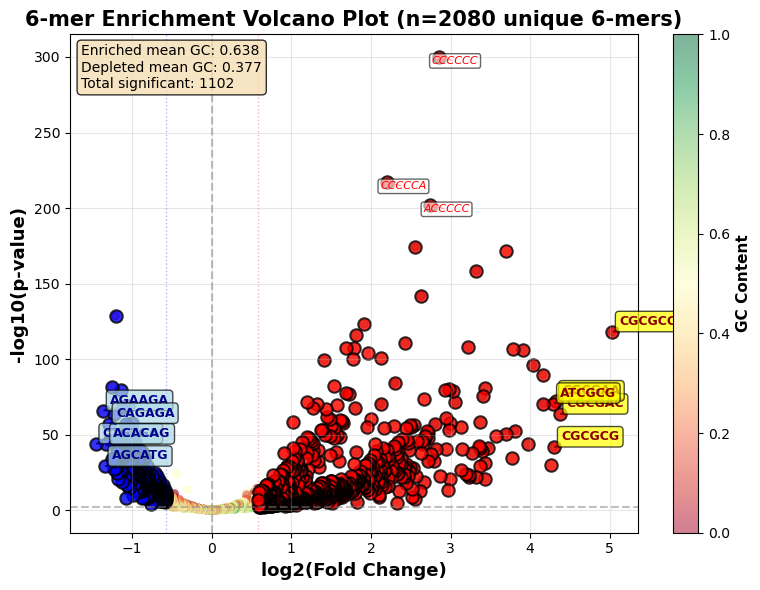

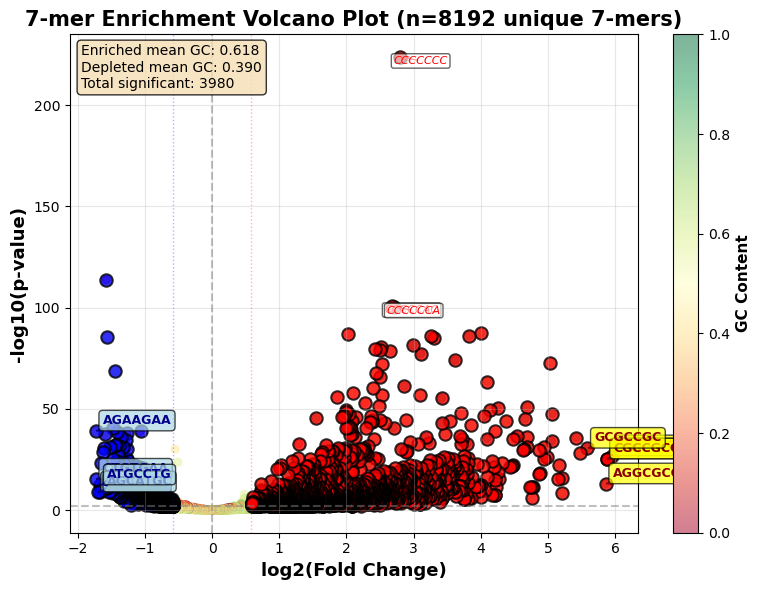

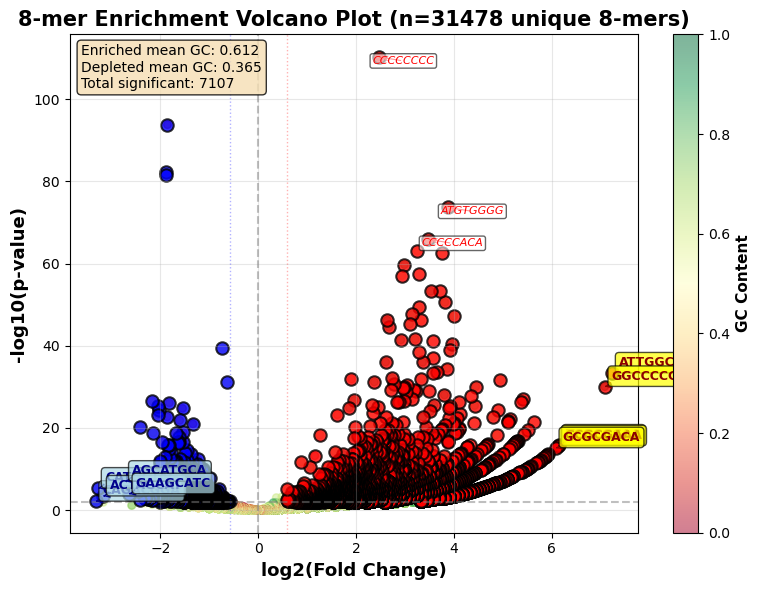


✓ All labeled volcano plots saved!


In [20]:
# ============= VOLCANO PLOT FOR EACH K WITH LABELS =============

for k in [2, 3, 4, 5, 6, 7, 8]:
    df_k = results_by_k[k]
    
    # Calculate -log10(p-value)
    df_k['-log10_pval'] = -np.log10(df_k['p_value'].clip(lower=1e-300))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot all points
    scatter = ax.scatter(df_k['log2_fc'], df_k['-log10_pval'], 
                        c=df_k['gc_content'], cmap='RdYlGn', 
                        alpha=0.5, s=30)
    
    # Mark significant
    significant = df_k['p_value'] < 0.01
    enriched = (df_k['fold_change'] > 1.5) & significant
    depleted = (df_k['fold_change'] < 0.67) & significant
    
    # Highlight enriched
    ax.scatter(df_k[enriched]['log2_fc'], df_k[enriched]['-log10_pval'],
              color='red', s=80, alpha=0.8, edgecolors='black', linewidths=1.5,
              label=f'Enriched (n={enriched.sum()})')
    
    # Highlight depleted
    ax.scatter(df_k[depleted]['log2_fc'], df_k[depleted]['-log10_pval'],
              color='blue', s=80, alpha=0.8, edgecolors='black', linewidths=1.5,
              label=f'Depleted (n={depleted.sum()})')
    
    # Add reference lines
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=-np.log10(0.01), color='gray', linestyle='--', alpha=0.5, 
               linewidth=1.5, label='p=0.01')
    ax.axvline(x=np.log2(1.5), color='red', linestyle=':', alpha=0.3, linewidth=1)
    ax.axvline(x=np.log2(0.67), color='blue', linestyle=':', alpha=0.3, linewidth=1)
    
    # Label top enriched k-mers (top 5 by fold change)
    top_enriched = df_k[enriched].nlargest(5, 'log2_fc')
    for _, row in top_enriched.iterrows():
        ax.annotate(row['kmer'], 
                   xy=(row['log2_fc'], row['-log10_pval']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, fontweight='bold', color='darkred',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', color='darkred', lw=1))
    
    # Label top depleted k-mers (top 5 by fold change)
    top_depleted = df_k[depleted].nsmallest(5, 'log2_fc')
    for _, row in top_depleted.iterrows():
        ax.annotate(row['kmer'], 
                   xy=(row['log2_fc'], row['-log10_pval']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, fontweight='bold', color='darkblue',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', color='darkblue', lw=1))
    
    # Label most significant k-mers (top 3 by p-value among enriched/depleted)
    top_significant_enriched = df_k[enriched].nsmallest(3, 'p_value')
    for _, row in top_significant_enriched.iterrows():
        # Skip if already labeled
        if row['kmer'] not in top_enriched['kmer'].values:
            ax.annotate(row['kmer'], 
                       xy=(row['log2_fc'], row['-log10_pval']),
                       xytext=(-5, -5), textcoords='offset points',
                       fontsize=8, color='red', style='italic',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6),
                       arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
    
    ax.set_xlabel('log2(Fold Change)', fontsize=13, fontweight='bold')
    ax.set_ylabel('-log10(p-value)', fontsize=13, fontweight='bold')
    ax.set_title(f'{k}-mer Enrichment Volcano Plot (n={len(df_k)} unique {k}-mers)', 
                 fontsize=15, fontweight='bold')
    
    # ax.legend(fontsize=11, loc='upper center')
    ax.grid(alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='GC Content')
    cbar.set_label('GC Content', fontsize=11, fontweight='bold')
    
    # Add statistics
    mean_gc_enriched = df_k[enriched]['gc_content'].mean() if enriched.sum() > 0 else 0
    mean_gc_depleted = df_k[depleted]['gc_content'].mean() if depleted.sum() > 0 else 0
    
    textstr = (f'Enriched mean GC: {mean_gc_enriched:.3f}\n'
               f'Depleted mean GC: {mean_gc_depleted:.3f}\n'
               f'Total significant: {(enriched.sum() + depleted.sum())}')
    
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'/scratch1/smaruj/suppressing_CTCFs/volcano_{k}mer_labeled.png', 
    #             dpi=300, bbox_inches='tight')
    plt.close()
    
    # print(f"✓ Saved {k}-mer volcano plot with labels")

print("\n✓ All labeled volcano plots saved!")

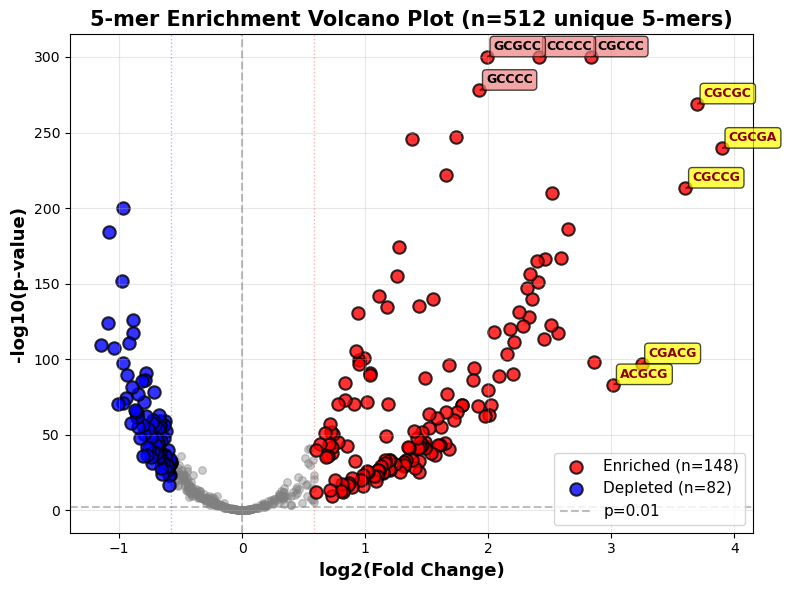

In [32]:
k = 5
df_k = results_by_k[k].copy()

# Calculate -log10(p-value)
df_k['-log10_pval'] = -np.log10(df_k['p_value'].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(8, 6))

# Define categories
significant = df_k['p_value'] < 0.01
enriched = (df_k['fold_change'] > 1.5) & significant
depleted = (df_k['fold_change'] < 0.67) & significant
nonsig = ~enriched & ~depleted

# Plot non-significant in gray
ax.scatter(df_k[nonsig]['log2_fc'], df_k[nonsig]['-log10_pval'],
           color='gray', alpha=0.4, s=30)

# Highlight enriched
ax.scatter(df_k[enriched]['log2_fc'], df_k[enriched]['-log10_pval'],
           color='red', s=80, alpha=0.8, edgecolors='black', linewidths=1.5,
           label=f'Enriched (n={enriched.sum()})')

# Highlight depleted
ax.scatter(df_k[depleted]['log2_fc'], df_k[depleted]['-log10_pval'],
           color='blue', s=80, alpha=0.8, edgecolors='black', linewidths=1.5,
           label=f'Depleted (n={depleted.sum()})')

# Reference lines
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axhline(y=-np.log10(0.01), color='gray', linestyle='--', alpha=0.5,
           linewidth=1.5, label='p=0.01')
ax.axvline(x=np.log2(1.5), color='red', linestyle=':', alpha=0.3, linewidth=1)
ax.axvline(x=np.log2(0.67), color='blue', linestyle=':', alpha=0.3, linewidth=1)

# Label top 5 enriched k-mers by fold change
top_enriched = df_k[enriched].nlargest(5, 'log2_fc')
already_labeled = set(top_enriched['kmer'].values)

for _, row in top_enriched.iterrows():
    ax.annotate(row['kmer'],
                xy=(row['log2_fc'], row['-log10_pval']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1))

# Label top 5 most significant points (by -log10 p-value), skip if already labeled
top_pval = df_k.nlargest(4, '-log10_pval')
for _, row in top_pval.iterrows():
    if row['kmer'] not in already_labeled:
        ax.annotate(row['kmer'],
                    xy=(row['log2_fc'], row['-log10_pval']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, color='black', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', color='darkred', lw=1))
    already_labeled.add(row['kmer'])

ax.set_xlabel('log2(Fold Change)', fontsize=13, fontweight='bold')
ax.set_ylabel('-log10(p-value)', fontsize=13, fontweight='bold')
ax.set_title(f'5-mer Enrichment Volcano Plot (n={len(df_k)} unique 5-mers)',
             fontsize=15, fontweight='bold')

ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('volcano_5mer_labeled.svg', dpi=300, bbox_inches='tight', format="svg")
plt.show()
plt.close()

In [ ]:
# ============= COMPREHENSIVE STATISTICS FOR EACH K =============

print("\n" + "="*80)
print("COMPREHENSIVE K-MER ENRICHMENT STATISTICS")
print("="*80)

for k in [3, 4, 5, 6, 7, 8]:
    df_k = results_by_k[k]
    
    print(f"\n{'='*80}")
    print(f"{k}-MER ANALYSIS")
    print(f"{'='*80}")
    
    # Basic statistics
    print(f"\nBasic Statistics:")
    print(f"  Total unique {k}-mers: {len(df_k)}")
    print(f"  Mean fold change: {df_k['fold_change'].mean():.3f}")
    print(f"  Median fold change: {df_k['fold_change'].median():.3f}")
    print(f"  Mean GC content: {df_k['gc_content'].mean():.3f}")
    
    # Enrichment/Depletion counts
    enriched = df_k[df_k['fold_change'] > 1.5]
    depleted = df_k[df_k['fold_change'] < 0.67]
    sig_enriched = df_k[(df_k['fold_change'] > 1.5) & (df_k['p_value'] < 0.01)]
    sig_depleted = df_k[(df_k['fold_change'] < 0.67) & (df_k['p_value'] < 0.01)]
    
    print(f"\nEnrichment Categories:")
    print(f"  Enriched (>1.5x): {len(enriched)} ({100*len(enriched)/len(df_k):.1f}%)")
    print(f"    - Mean GC: {enriched['gc_content'].mean():.3f}")
    print(f"    - Significantly enriched (p<0.01): {len(sig_enriched)}")
    print(f"  Depleted (<0.67x): {len(depleted)} ({100*len(depleted)/len(df_k):.1f}%)")
    print(f"    - Mean GC: {depleted['gc_content'].mean():.3f}")
    print(f"    - Significantly depleted (p<0.01): {len(sig_depleted)}")
    print(f"  Neutral (0.67-1.5x): {len(df_k) - len(enriched) - len(depleted)}")
    
    # Extreme values
    most_enriched = df_k.nlargest(1, 'fold_change').iloc[0]
    most_depleted = df_k.nsmallest(1, 'fold_change').iloc[0]
    most_significant = df_k.nsmallest(1, 'p_value').iloc[0]
    
    print(f"\nExtreme Cases:")
    print(f"  Most enriched: {most_enriched['kmer']} ({most_enriched['fold_change']:.2f}x, p={most_enriched['p_value']:.2e})")
    print(f"  Most depleted: {most_depleted['kmer']} ({most_depleted['fold_change']:.2f}x, p={most_depleted['p_value']:.2e})")
    print(f"  Most significant: {most_significant['kmer']} ({most_significant['fold_change']:.2f}x, p={most_significant['p_value']:.2e})")
    
    # Homopolymer analysis
    homopolymers = df_k[df_k['kmer'].apply(lambda x: len(set(x)) == 1)]
    print(f"\nHomopolymers:")
    print(f"  Total homopolymers: {len(homopolymers)}")
    if len(homopolymers) > 0:
        for _, row in homopolymers.iterrows():
            print(f"    {row['kmer']}: {row['fold_change']:.2f}x (p={row['p_value']:.2e})")
    
    # Top 20 enriched k-mers
    print(f"\n{'='*60}")
    print(f"TOP 20 MOST ENRICHED {k}-MERS")
    print(f"{'='*60}")
    top20_enriched = df_k.nlargest(20, 'fold_change')
    print(f"{'Rank':<6}{'K-mer':<12}{'Fold Change':<15}{'GC Content':<12}{'p-value':<12}{'Orig Count':<12}{'Edit Count':<12}")
    print("-" * 80)
    for rank, (_, row) in enumerate(top20_enriched.iterrows(), 1):
        print(f"{rank:<6}{row['kmer']:<12}{row['fold_change']:<15.2f}{row['gc_content']:<12.3f}"
              f"{row['p_value']:<12.2e}{row['orig_count']:<12}{row['edited_count']:<12}")
    
    # Top 20 depleted k-mers
    print(f"\n{'='*60}")
    print(f"TOP 20 MOST DEPLETED {k}-MERS")
    print(f"{'='*60}")
    top20_depleted = df_k.nsmallest(20, 'fold_change')
    print(f"{'Rank':<6}{'K-mer':<12}{'Fold Change':<15}{'GC Content':<12}{'p-value':<12}{'Orig Count':<12}{'Edit Count':<12}")
    print("-" * 80)
    for rank, (_, row) in enumerate(top20_depleted.iterrows(), 1):
        print(f"{rank:<6}{row['kmer']:<12}{row['fold_change']:<15.2f}{row['gc_content']:<12.3f}"
              f"{row['p_value']:<12.2e}{row['orig_count']:<12}{row['edited_count']:<12}")
    
    # Top 10 most significant (by p-value) among enriched
    print(f"\n{'='*60}")
    print(f"TOP 10 MOST SIGNIFICANT ENRICHED {k}-MERS (by p-value)")
    print(f"{'='*60}")
    top10_sig = df_k[df_k['fold_change'] > 1.5].nsmallest(10, 'p_value')
    print(f"{'Rank':<6}{'K-mer':<12}{'Fold Change':<15}{'GC Content':<12}{'p-value':<12}")
    print("-" * 70)
    for rank, (_, row) in enumerate(top10_sig.iterrows(), 1):
        print(f"{rank:<6}{row['kmer']:<12}{row['fold_change']:<15.2f}{row['gc_content']:<12.3f}{row['p_value']:<12.2e}")

# ============= SAVE SUMMARY STATISTICS TO FILE =============

summary_output = '/scratch1/smaruj/suppressing_CTCFs/kmer_enrichment_summary.txt'

with open(summary_output, 'w') as f:
    f.write("="*80 + "\n")
    f.write("K-MER ENRICHMENT ANALYSIS SUMMARY\n")
    f.write("="*80 + "\n\n")
    
    for k in [3, 4, 5, 6, 7, 8]:
        df_k = results_by_k[k]
        
        f.write(f"\n{'='*80}\n")
        f.write(f"{k}-MER ANALYSIS\n")
        f.write(f"{'='*80}\n\n")
        
        # Basic stats
        enriched = df_k[df_k['fold_change'] > 1.5]
        depleted = df_k[df_k['fold_change'] < 0.67]
        sig_enriched = df_k[(df_k['fold_change'] > 1.5) & (df_k['p_value'] < 0.01)]
        
        f.write(f"Total unique {k}-mers: {len(df_k)}\n")
        f.write(f"Enriched (>1.5x): {len(enriched)} (mean GC: {enriched['gc_content'].mean():.3f})\n")
        f.write(f"Significantly enriched (p<0.01): {len(sig_enriched)}\n")
        f.write(f"Depleted (<0.67x): {len(depleted)} (mean GC: {depleted['gc_content'].mean():.3f})\n\n")
        
        # Top 20 enriched
        f.write(f"TOP 20 MOST ENRICHED {k}-MERS:\n")
        f.write("-" * 80 + "\n")
        top20 = df_k.nlargest(20, 'fold_change')
        for rank, (_, row) in enumerate(top20.iterrows(), 1):
            f.write(f"{rank:2d}. {row['kmer']:<10} | FC: {row['fold_change']:6.2f}x | "
                   f"GC: {row['gc_content']:.3f} | p: {row['p_value']:.2e}\n")
        
        f.write("\n")

print(f"\n✓ Summary statistics saved to: {summary_output}")

# ============= CREATE SUMMARY TABLE =============

summary_table = []
for k in [3, 4, 5, 6, 7, 8]:
    df_k = results_by_k[k]
    enriched = df_k[df_k['fold_change'] > 1.5]
    depleted = df_k[df_k['fold_change'] < 0.67]
    sig_enriched = df_k[(df_k['fold_change'] > 1.5) & (df_k['p_value'] < 0.01)]
    sig_depleted = df_k[(df_k['fold_change'] < 0.67) & (df_k['p_value'] < 0.01)]
    
    summary_table.append({
        'k': k,
        'total_kmers': len(df_k),
        'enriched': len(enriched),
        'enriched_pct': 100 * len(enriched) / len(df_k),
        'enriched_mean_gc': enriched['gc_content'].mean(),
        'sig_enriched': len(sig_enriched),
        'depleted': len(depleted),
        'depleted_pct': 100 * len(depleted) / len(df_k),
        'depleted_mean_gc': depleted['gc_content'].mean(),
        'sig_depleted': len(sig_depleted)
    })

summary_df = pd.DataFrame(summary_table)

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))

# summary_df.to_csv('/scratch1/smaruj/suppressing_CTCFs/kmer_summary_table.tsv', 
#                   sep='\t', index=False)
# print("\n✓ Summary table saved to: /scratch1/smaruj/suppressing_CTCFs/kmer_summary_table.tsv")

In [ ]:
# ============= VISUALIZATION =============

# Create comprehensive visualization
fig, axes = plt.subplots(7, 2, figsize=(16, 30))

# For each k-mer size, create a volcano plot
for idx, k in enumerate([2, 3, 4, 5, 6, 7, 8]):
    ax = axes[idx, 0]
    df_k = results_by_k[k]
    
    # Volcano plot: log2(FC) vs -log10(p-value)
    df_k['-log10_pval'] = -np.log10(df_k['p_value'].clip(lower=1e-300))
    
    scatter = ax.scatter(df_k['log2_fc'], df_k['-log10_pval'], 
                        c=df_k['gc_content'], cmap='RdYlGn', 
                        alpha=0.6, s=20)
    
    # Mark significant enriched/depleted
    significant = df_k['p_value'] < 0.01
    enriched = (df_k['fold_change'] > 1.5) & significant
    depleted = (df_k['fold_change'] < 0.67) & significant
    
    ax.scatter(df_k[enriched]['log2_fc'], df_k[enriched]['-log10_pval'],
              color='red', s=50, alpha=0.8, edgecolors='black', label=f'Enriched (n={enriched.sum()})')
    ax.scatter(df_k[depleted]['log2_fc'], df_k[depleted]['-log10_pval'],
              color='blue', s=50, alpha=0.8, edgecolors='black', label=f'Depleted (n={depleted.sum()})')
    
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=-np.log10(0.01), color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel(f'log2(Fold Change)', fontsize=11)
    ax.set_ylabel(f'-log10(p-value)', fontsize=11)
    ax.set_title(f'{k}-mer Enrichment Volcano Plot', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.colorbar(scatter, ax=ax, label='GC Content')
    
    # Add labels for top enriched/depleted
    top_enriched = df_k.nlargest(3, 'log2_fc')
    for _, row in top_enriched.iterrows():
        if row['p_value'] < 0.01:
            ax.annotate(row['kmer'], 
                       (row['log2_fc'], row['-log10_pval']),
                       fontsize=8, alpha=0.7)
    
    top_depleted = df_k.nsmallest(3, 'log2_fc')
    for _, row in top_depleted.iterrows():
        if row['p_value'] < 0.01:
            ax.annotate(row['kmer'], 
                       (row['log2_fc'], row['-log10_pval']),
                       fontsize=8, alpha=0.7)
# GC content distribution for different k-mer sizes
for idx, k in enumerate([4, 5, 6]):
    ax = axes[idx, 1]
    df_k = results_by_k[k]
    
    # Separate by enrichment status
    enriched = df_k[df_k['fold_change'] > 1.5]
    depleted = df_k[df_k['fold_change'] < 0.67]
    neutral = df_k[(df_k['fold_change'] >= 0.67) & (df_k['fold_change'] <= 1.5)]
    
    ax.hist(enriched['gc_content'], bins=20, alpha=0.5, label='Enriched', color='red', density=True)
    ax.hist(depleted['gc_content'], bins=20, alpha=0.5, label='Depleted', color='blue', density=True)
    ax.hist(neutral['gc_content'], bins=20, alpha=0.3, label='Neutral', color='gray', density=True)
    
    ax.set_xlabel('GC Content', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{k}-mer GC Content by Enrichment', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/suppressing_CTCFs/kmer_enrichment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os

# Create output directory
output_dir = "/scratch1/smaruj/suppressing_CTCFs/dnashape_input/"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# ============= ORIGINAL SEQUENCES =============
print("Creating FASTA file for original sequences...")

with open(f"{output_dir}original_sequences.fasta", 'w') as f:
    for idx, row in df.iterrows():
        chrom = row["chrom"]
        cstart = row["centered_start"]
        cend = row["centered_end"]
        fold = row["fold"]
        
        # Load original
        orig_path = f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/{fold}/{chrom}_{cstart}_{cend}_X.pt"
        X = torch.load(orig_path, map_location='cpu')
        edit_start = (256 + 64) * 2048
        edit_end = edit_start + 2048
        orig_slice = X[:, :, edit_start:edit_end]
        orig_seq = tensor_to_sequence(orig_slice)
        
        # Write to FASTA
        header = f">{chrom}_{cstart}_{cend}_original_idx{idx}"
        f.write(f"{header}\n")
        f.write(f"{orig_seq}\n")

print(f"✓ Original sequences saved to: {output_dir}original_sequences.fasta")

In [ ]:
# ============= EDITED SEQUENCES =============
print("Creating FASTA file for edited sequences...")

with open(f"{output_dir}edited_sequences.fasta", 'w') as f:
    for idx, row in df.iterrows():
        chrom = row["chrom"]
        cstart = row["centered_start"]
        cend = row["centered_end"]
        fold = row["fold"]
        
        # Load edited
        edited_path = f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/{fold}/{chrom}_{cstart}_{cend}_slice.pt"
        edited_slice = torch.load(edited_path, map_location='cpu')
        edited_seq = tensor_to_sequence(edited_slice)
        
        # Write to FASTA
        header = f">{chrom}_{cstart}_{cend}_edited_idx{idx}"
        f.write(f"{header}\n")
        f.write(f"{edited_seq}\n")

print(f"✓ Edited sequences saved to: {output_dir}edited_sequences.fasta")

In [ ]:
# Stiffness parameters from Olson et al. (1998) PNAS
# Units: kcal/(mol·Å²) for shift/slide/rise, kcal/(mol·rad²) for tilt/roll/twist
DINUCLEOTIDE_STIFFNESS = {
    'AA': {'roll': 7.1, 'twist': 3.1},
    'AT': {'roll': 7.9, 'twist': 2.6},
    'TA': {'roll': 6.4, 'twist': 2.1},
    'TT': {'roll': 7.1, 'twist': 3.1},
    'AC': {'roll': 9.4, 'twist': 3.8},
    'CA': {'roll': 8.9, 'twist': 3.2},
    'AG': {'roll': 10.6, 'twist': 3.0},
    'GA': {'roll': 9.7, 'twist': 3.5},
    'TC': {'roll': 10.6, 'twist': 3.0},
    'CT': {'roll': 9.7, 'twist': 3.5},
    'TG': {'roll': 8.9, 'twist': 3.2},
    'GT': {'roll': 9.4, 'twist': 3.8},
    'CC': {'roll': 13.0, 'twist': 4.3},
    'CG': {'roll': 11.1, 'twist': 2.1},
    'GC': {'roll': 14.6, 'twist': 5.0},
    'GG': {'roll': 13.0, 'twist': 4.3},
}


In [ ]:
def calculate_sequence_rigidity(sequence):
    """
    Calculate average DNA rigidity for a sequence.
    Higher values = more rigid (harder to bend/twist)
    """
    sequence = sequence.upper()
    
    roll_stiffness = []
    twist_stiffness = []
    
    for i in range(len(sequence) - 1):
        dinuc = sequence[i:i+2]
        
        if dinuc in DINUCLEOTIDE_STIFFNESS:
            roll_stiffness.append(DINUCLEOTIDE_STIFFNESS[dinuc]['roll'])
            twist_stiffness.append(DINUCLEOTIDE_STIFFNESS[dinuc]['twist'])
    
    return {
        'mean_roll_stiffness': np.mean(roll_stiffness) if roll_stiffness else 0,
        'mean_twist_stiffness': np.mean(twist_stiffness) if twist_stiffness else 0,
        'total_rigidity': np.mean(roll_stiffness + twist_stiffness) if (roll_stiffness or twist_stiffness) else 0
    }

In [ ]:
# Analyze your sequences
rigidity_results = []

for idx, row in df.iterrows():
    chrom = row["chrom"]
    cstart = row["centered_start"]
    cend = row["centered_end"]
    fold = row["fold"]
    
    # Load original
    orig_path = f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/{fold}/{chrom}_{cstart}_{cend}_X.pt"
    X = torch.load(orig_path, map_location='cpu')
    edit_start = (256 + 64) * 2048
    edit_end = edit_start + 2048
    orig_slice = X[:, :, edit_start:edit_end]
    orig_seq = tensor_to_sequence(orig_slice)
    
    # Load edited
    edited_path = f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/{fold}/{chrom}_{cstart}_{cend}_slice.pt"
    edited_slice = torch.load(edited_path, map_location='cpu')
    edited_seq = tensor_to_sequence(edited_slice)
    
    # Calculate rigidity
    orig_rig = calculate_sequence_rigidity(orig_seq)
    edited_rig = calculate_sequence_rigidity(edited_seq)
    
    rigidity_results.append({
        'idx': idx,
        'orig_roll_stiffness': orig_rig['mean_roll_stiffness'],
        'orig_twist_stiffness': orig_rig['mean_twist_stiffness'],
        'orig_total_rigidity': orig_rig['total_rigidity'],
        'edited_roll_stiffness': edited_rig['mean_roll_stiffness'],
        'edited_twist_stiffness': edited_rig['mean_twist_stiffness'],
        'edited_total_rigidity': edited_rig['total_rigidity'],
    })

rigidity_df = pd.DataFrame(rigidity_results)

In [ ]:
# Merge with main df
for col in ['orig_roll_stiffness', 'orig_twist_stiffness', 'orig_total_rigidity',
            'edited_roll_stiffness', 'edited_twist_stiffness', 'edited_total_rigidity']:
    df[col] = rigidity_df[col]

In [ ]:
# Analysis
print("\n" + "="*80)
print("DNA RIGIDITY ANALYSIS")
print("="*80)

print(f"\nOriginal sequences:")
print(f"  Roll stiffness:  {df['orig_roll_stiffness'].mean():.3f} ± {df['orig_roll_stiffness'].std():.3f}")
print(f"  Twist stiffness: {df['orig_twist_stiffness'].mean():.3f} ± {df['orig_twist_stiffness'].std():.3f}")
print(f"  Total rigidity:  {df['orig_total_rigidity'].mean():.3f} ± {df['orig_total_rigidity'].std():.3f}")

print(f"\nEdited sequences:")
print(f"  Roll stiffness:  {df['edited_roll_stiffness'].mean():.3f} ± {df['edited_roll_stiffness'].std():.3f}")
print(f"  Twist stiffness: {df['edited_twist_stiffness'].mean():.3f} ± {df['edited_twist_stiffness'].std():.3f}")
print(f"  Total rigidity:  {df['edited_total_rigidity'].mean():.3f} ± {df['edited_total_rigidity'].std():.3f}")

In [ ]:
# Statistical test
from scipy import stats

t_roll, p_roll = stats.ttest_rel(df['orig_roll_stiffness'], df['edited_roll_stiffness'])
t_twist, p_twist = stats.ttest_rel(df['orig_twist_stiffness'], df['edited_twist_stiffness'])
t_total, p_total = stats.ttest_rel(df['orig_total_rigidity'], df['edited_total_rigidity'])

print(f"\nPaired t-tests:")
print(f"  Roll stiffness:  t={t_roll:.3f}, p={p_roll:.3e}")
print(f"  Twist stiffness: t={t_twist:.3f}, p={p_twist:.3e}")
print(f"  Total rigidity:  t={t_total:.3f}, p={p_total:.3e}")

# Correlation with URQ
corr_rig_urq, p_rig_urq = stats.pearsonr(df['edited_total_rigidity'], df['URQ_result'])
print(f"\nCorrelation between rigidity and boundary suppression:")
print(f"  r={corr_rig_urq:.3f}, p={p_rig_urq:.3e}")

In [ ]:
# ============= SAVE RESULTS =============

# Save enrichment tables
for k in k_sizes:
    output_path = f'/scratch1/smaruj/suppressing_CTCFs/kmer_enrichment_{k}mer.tsv'
    results_by_k[k].to_csv(output_path, sep='\t', index=False)
    print(f"Saved {k}-mer results to {output_path}")

In [ ]:
# ============= SUMMARY STATISTICS =============

print("\n" + "="*80)
print("SUMMARY: K-mer Enrichment Analysis")
print("="*80)

for k in k_sizes:
    df_k = results_by_k[k]
    enriched = df_k[df_k['fold_change'] > 1.5]
    depleted = df_k[df_k['fold_change'] < 0.67]
    
    print(f"\n{k}-mers:")
    print(f"  Total unique k-mers: {len(df_k)}")
    print(f"  Enriched (>1.5x): {len(enriched)} (mean GC: {enriched['gc_content'].mean():.3f})")
    print(f"  Depleted (<0.67x): {len(depleted)} (mean GC: {depleted['gc_content'].mean():.3f})")
    print(f"  Significantly enriched (p<0.01): {((df_k['fold_change'] > 1.5) & (df_k['p_value'] < 0.01)).sum()}")
    print(f"  Significantly depleted (p<0.01): {((df_k['fold_change'] < 0.67) & (df_k['p_value'] < 0.01)).sum()}")

print("\n✓ K-mer analysis complete!")

In [ ]:
import re
from collections import Counter

def find_homopolymer_runs(sequence, min_length=5):
    """Find homopolymer runs (e.g., AAAAA, GGGGG, CCCCC, TTTTT)."""
    runs = {
        'A': [],
        'C': [],
        'G': [],
        'T': []
    }
    
    for base in ['A', 'C', 'G', 'T']:
        pattern = f'{base}{{{min_length},}}'  # e.g., 'C{5,}' matches CCCCC or longer
        for match in re.finditer(pattern, sequence):
            runs[base].append({
                'position': match.start(),
                'length': len(match.group()),
                'sequence': match.group()
            })
    
    return runs

In [ ]:
# Analyze homopolymer runs in original vs edited slices
homopolymer_stats = {
    'original': {'A': [], 'C': [], 'G': [], 'T': []},
    'edited': {'A': [], 'C': [], 'G': [], 'T': []}
}

for idx, row in df.iterrows():
    chrom = row["chrom"]
    cstart = row["centered_start"]
    cend = row["centered_end"]
    fold = row["fold"]
    
    # Load original
    orig_path = f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/{fold}/{chrom}_{cstart}_{cend}_X.pt"
    X = torch.load(orig_path, map_location='cpu')
    edit_start = (256 + 64) * 2048
    edit_end = edit_start + 2048
    orig_slice = X[:, :, edit_start:edit_end]
    orig_seq = tensor_to_sequence(orig_slice)
    
    # Load edited
    edited_path = f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/{fold}/{chrom}_{cstart}_{cend}_slice.pt"
    edited_slice = torch.load(edited_path, map_location='cpu')
    edited_seq = tensor_to_sequence(edited_slice)
    
    # Find homopolymer runs (5+ bp)
    orig_runs = find_homopolymer_runs(orig_seq, min_length=5)
    edited_runs = find_homopolymer_runs(edited_seq, min_length=5)
    
    # Count and store lengths
    for base in ['A', 'C', 'G', 'T']:
        homopolymer_stats['original'][base].extend([r['length'] for r in orig_runs[base]])
        homopolymer_stats['edited'][base].extend([r['length'] for r in edited_runs[base]])


In [ ]:
# Summary statistics
print("\n" + "="*80)
print("HOMOPOLYMER RUN ANALYSIS (≥5bp)")
print("="*80)

for base in ['A', 'C', 'G', 'T']:
    orig_counts = homopolymer_stats['original'][base]
    edited_counts = homopolymer_stats['edited'][base]
    
    print(f"\n{base}-runs:")
    print(f"  Original: {len(orig_counts)} runs, mean length: {np.mean(orig_counts) if orig_counts else 0:.2f}, max: {max(orig_counts) if orig_counts else 0}")
    print(f"  Edited:   {len(edited_counts)} runs, mean length: {np.mean(edited_counts) if edited_counts else 0:.2f}, max: {max(edited_counts) if edited_counts else 0}")
    print(f"  Fold change: {len(edited_counts) / max(len(orig_counts), 1):.2f}x")

In [ ]:
c_orig_lengths = Counter(homopolymer_stats['original']['C'])
c_edited_lengths = Counter(homopolymer_stats['edited']['C'])

print("\nOriginal C-runs by length:")
for length in sorted(set(c_orig_lengths.keys()) | set(c_edited_lengths.keys())):
    print(f"  {length}bp: {c_orig_lengths[length]} runs")

print("\nEdited C-runs by length:")
for length in sorted(set(c_orig_lengths.keys()) | set(c_edited_lengths.keys())):
    print(f"  {length}bp: {c_edited_lengths[length]} runs")

print("\n" + "="*80)
print("G-RUN LENGTH DISTRIBUTION")
print("="*80)

g_orig_lengths = Counter(homopolymer_stats['original']['G'])
g_edited_lengths = Counter(homopolymer_stats['edited']['G'])

print("\nOriginal G-runs by length:")
for length in sorted(set(g_orig_lengths.keys()) | set(g_edited_lengths.keys())):
    print(f"  {length}bp: {g_orig_lengths[length]} runs")

print("\nEdited G-runs by length:")
for length in sorted(set(g_orig_lengths.keys()) | set(g_edited_lengths.keys())):
    print(f"  {length}bp: {g_edited_lengths[length]} runs")

In [ ]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bases = ['A', 'C', 'G', 'T']
colors = ['red', 'blue', 'orange', 'green']

for idx, (base, color) in enumerate(zip(bases, colors)):
    ax = axes[idx // 2, idx % 2]
    
    orig_data = homopolymer_stats['original'][base]
    edited_data = homopolymer_stats['edited'][base]
    
    if orig_data or edited_data:
        bins = range(5, max(max(orig_data, default=5), max(edited_data, default=5)) + 2)
        
        ax.hist(orig_data, bins=bins, alpha=0.5, label='Original', color='gray', edgecolor='black')
        ax.hist(edited_data, bins=bins, alpha=0.5, label='Edited (Suppressed)', color=color, edgecolor='black')
        
        ax.set_xlabel(f'{base}-run Length (bp)', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'{base}-homopolymer Runs (≥5bp)', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')
        
        # Add statistics text
        if orig_data:
            orig_text = f"Orig: n={len(orig_data)}, max={max(orig_data)}"
        else:
            orig_text = "Orig: n=0"
            
        if edited_data:
            edited_text = f"Edit: n={len(edited_data)}, max={max(edited_data)}"
        else:
            edited_text = "Edit: n=0"
        
        ax.text(0.95, 0.95, f"{orig_text}\n{edited_text}", 
                transform=ax.transAxes, fontsize=9, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/suppressing_CTCFs/homopolymer_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Statistical test for C and G runs
from scipy import stats

print("\n" + "="*80)
print("STATISTICAL TESTS")
print("="*80)

for base in ['C', 'G']:
    orig_count = len(homopolymer_stats['original'][base])
    edited_count = len(homopolymer_stats['edited'][base])
    
    # Chi-square test for count difference
    total = orig_count + edited_count
    expected = total / 2
    
    if total > 0:
        chi2 = ((orig_count - expected)**2 / expected + 
                (edited_count - expected)**2 / expected)
        p_val = 1 - stats.chi2.cdf(chi2, df=1)
        
        print(f"\n{base}-runs count difference:")
        print(f"  Original: {orig_count}")
        print(f"  Edited: {edited_count}")
        print(f"  Chi-square: {chi2:.3f}, p-value: {p_val:.3e}")

print("\n✓ Homopolymer analysis complete!")

In [ ]:
### How many homopolymers overlap new CTCFs?

In [ ]:
import re
import numpy as np
from collections import defaultdict

In [ ]:
def find_homopolymer_positions(sequence, min_length=4):
    """Find positions of all G and C homopolymers."""
    homopolymers = []
    
    # Find C homopolymers
    for match in re.finditer(f'C{{{min_length},}}', sequence):
        homopolymers.append({
            'type': 'poly-C',
            'start': match.start(),
            'end': match.end(),
            'length': len(match.group()),
            'sequence': match.group()
        })
    
    # Find G homopolymers
    for match in re.finditer(f'G{{{min_length},}}', sequence):
        homopolymers.append({
            'type': 'poly-G',
            'start': match.start(),
            'end': match.end(),
            'length': len(match.group()),
            'sequence': match.group()
        })
    
    return homopolymers

In [ ]:
def check_overlap(region1_start, region1_end, region2_start, region2_end):
    """Check if two regions overlap and return overlap length."""
    overlap_start = max(region1_start, region2_start)
    overlap_end = min(region1_end, region2_end)
    
    if overlap_start < overlap_end:
        return overlap_end - overlap_start
    return 0

def calculate_distance(region1_start, region1_end, region2_start, region2_end):
    """Calculate distance between two regions (0 if overlapping)."""
    if check_overlap(region1_start, region1_end, region2_start, region2_end) > 0:
        return 0
    
    # Distance is the gap between regions
    if region1_end <= region2_start:
        return region2_start - region1_end
    else:
        return region1_start - region2_end

In [ ]:
# Storage for results
overlap_stats = {
    'total_new_ctcfs': 0,
    'ctcfs_with_homopolymer_overlap': 0,
    'ctcfs_with_polyc': 0,
    'ctcfs_with_polyg': 0,
    'ctcfs_with_both': 0,
    'total_homopolymers': 0,
    'homopolymers_in_ctcfs': 0,
    'overlap_lengths': [],
    'distances_to_nearest': [],
    'ctcf_gc_content': [],
    'overlapping_ctcf_gc': [],
    'non_overlapping_ctcf_gc': []
}

detailed_overlaps = []

for idx, row in df.iterrows():
    chrom = row["chrom"]
    cstart = row["centered_start"]
    cend = row["centered_end"]
    fold = row["fold"]
    
    # Load edited sequence
    edited_path = f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/{fold}/{chrom}_{cstart}_{cend}_slice.pt"
    edited_slice = torch.load(edited_path, map_location='cpu')
    edited_seq = tensor_to_sequence(edited_slice)
    
    # Get new CTCFs
    if 'new_CTCFs_coord' not in row or not row['new_CTCFs_coord']:
        continue
    
    new_ctcfs = row['new_CTCFs_coord']
    if isinstance(new_ctcfs, str):
        import ast
        new_ctcfs = ast.literal_eval(new_ctcfs)
    
    # Find all homopolymers
    homopolymers = find_homopolymer_positions(edited_seq, min_length=4)
    
    overlap_stats['total_homopolymers'] += len(homopolymers)
    
    # Check each new CTCF
    for ctcf_start, ctcf_end, strand in new_ctcfs:
        if not (0 <= ctcf_start < 2048 and 0 <= ctcf_end <= 2048):
            continue
        
        overlap_stats['total_new_ctcfs'] += 1
        
        # Calculate CTCF GC content
        ctcf_seq = edited_seq[ctcf_start:ctcf_end]
        ctcf_gc = (ctcf_seq.count('G') + ctcf_seq.count('C')) / len(ctcf_seq)
        overlap_stats['ctcf_gc_content'].append(ctcf_gc)
        
        # Check for overlaps with homopolymers
        has_overlap = False
        has_polyc = False
        has_polyg = False
        overlapping_homopolymers = []
        
        min_distance = float('inf')
        
        for homopoly in homopolymers:
            overlap_len = check_overlap(ctcf_start, ctcf_end, 
                                       homopoly['start'], homopoly['end'])
            
            distance = calculate_distance(ctcf_start, ctcf_end,
                                         homopoly['start'], homopoly['end'])
            min_distance = min(min_distance, distance)
            
            if overlap_len > 0:
                has_overlap = True
                overlapping_homopolymers.append(homopoly)
                overlap_stats['overlap_lengths'].append(overlap_len)
                
                if homopoly['type'] == 'poly-C':
                    has_polyc = True
                elif homopoly['type'] == 'poly-G':
                    has_polyg = True
                
                detailed_overlaps.append({
                    'seq_idx': idx,
                    'ctcf_start': ctcf_start,
                    'ctcf_end': ctcf_end,
                    'ctcf_strand': strand,
                    'ctcf_gc': ctcf_gc,
                    'homopoly_type': homopoly['type'],
                    'homopoly_start': homopoly['start'],
                    'homopoly_end': homopoly['end'],
                    'homopoly_length': homopoly['length'],
                    'overlap_length': overlap_len,
                    'ctcf_length': ctcf_end - ctcf_start,
                    'overlap_fraction': overlap_len / (ctcf_end - ctcf_start)
                })
            
        if has_overlap:
            overlap_stats['ctcfs_with_homopolymer_overlap'] += 1
            overlap_stats['overlapping_ctcf_gc'].append(ctcf_gc)
            overlap_stats['homopolymers_in_ctcfs'] += len(overlapping_homopolymers)
            
            if has_polyc:
                overlap_stats['ctcfs_with_polyc'] += 1
            if has_polyg:
                overlap_stats['ctcfs_with_polyg'] += 1
            if has_polyc and has_polyg:
                overlap_stats['ctcfs_with_both'] += 1
        else:
            overlap_stats['non_overlapping_ctcf_gc'].append(ctcf_gc)
        
        if min_distance < float('inf'):
            overlap_stats['distances_to_nearest'].append(min_distance)

In [ ]:
print(f"\nOVERALL STATISTICS:")
print(f"  Total new CTCFs analyzed: {overlap_stats['total_new_ctcfs']}")
print(f"  Total G/C homopolymers (≥4bp): {overlap_stats['total_homopolymers']}")

print(f"\nCTCF-HOMOPOLYMER OVERLAP:")
print(f"  New CTCFs overlapping homopolymers: {overlap_stats['ctcfs_with_homopolymer_overlap']}/{overlap_stats['total_new_ctcfs']} "
      f"({100*overlap_stats['ctcfs_with_homopolymer_overlap']/overlap_stats['total_new_ctcfs']:.1f}%)")

In [ ]:
print(f"\n  By homopolymer type:")
print(f"    Overlapping poly-C: {overlap_stats['ctcfs_with_polyc']} "
      f"({100*overlap_stats['ctcfs_with_polyc']/overlap_stats['total_new_ctcfs']:.1f}%)")
print(f"    Overlapping poly-G: {overlap_stats['ctcfs_with_polyg']} "
      f"({100*overlap_stats['ctcfs_with_polyg']/overlap_stats['total_new_ctcfs']:.1f}%)")
print(f"    Overlapping both: {overlap_stats['ctcfs_with_both']} "
      f"({100*overlap_stats['ctcfs_with_both']/overlap_stats['total_new_ctcfs']:.1f}%)")

print(f"\nHOMOPOLYMERS IN CTCFs:")
print(f"  Homopolymers overlapping CTCFs: {overlap_stats['homopolymers_in_ctcfs']}/{overlap_stats['total_homopolymers']} "
      f"({100*overlap_stats['homopolymers_in_ctcfs']/overlap_stats['total_homopolymers']:.1f}%)")

In [ ]:
import torch
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [ ]:
# ============= DEFINE MOTIF/ELEMENT PATTERNS =============

# ID element consensus (MIR family - GC-rich)
ID_CONSENSUS = "GGGGGCGGGGCGGGGGCGGGCGGGGCGGGGCGGGCGGCGGGCGGGGCGGGGCGGCGGGCGGGGCGGGGCGGCGGGCGGGG"

# B1 SINE (partial - has poly-C regions)
B1_PARTIAL = "CCCCCCAGCACTCGGGAGGCAGAGGCAGGCGGATTTCTGAGTTCGAGGCCAGCCT"

# SINE B2 (that we tested before)
SINEB2 = "GGGGCTGGAGAGATGGCTCAGCGGTTAAGAGCACTGACTGCTCTTCCAGAGGTCCTGAGTTCAATTCCCAGCAACCACATGGTGGCTCACAACCATCTGTAATGGGATCTGATGCCCTCTTCTGGTGTGTCTGAAGACAGCTACAGTGTACTCACATACATAAATAAATAAATAAATCTTTAAAAAAAAAAAAAA"

# SP1 binding motif
SP1_MOTIF = "GGGGCGGGG"

# EGR motif  
EGR_MOTIF = "GCGGGGGCG"

# G-quadruplex pattern (simplified)
G4_PATTERN = "GGGNGGGNGGGNGGG"  # We'll search for simpler GGGNGGGNGGGNGG

# Simple poly-G/C patterns
POLY_G_5 = "GGGGG"
POLY_C_5 = "CCCCC"
POLY_G_6 = "GGGGGG"
POLY_C_6 = "CCCCCC"
POLY_G_7 = "GGGGGGG"
POLY_C_7 = "CCCCCCC"
POLY_G_8 = "GGGGGGGG"
POLY_C_8 = "CCCCCCCC"

# CpG-rich patterns
CPG_ISLAND_LIKE = "CGCGCGCG"
GC_REPEAT = "GCGCGCGC"

In [ ]:
print("="*80)
print("COMPARATIVE MOTIF/ELEMENT SCANNING")
print("="*80)

# Storage for results
results = {
    'id_element': {'orig': [], 'edited': []},
    'b1_sine': {'orig': [], 'edited': []},
    'sineb2': {'orig': [], 'edited': []},
    'sp1': {'orig': [], 'edited': []},
    'egr': {'orig': [], 'edited': []},
    'poly_g5': {'orig': [], 'edited': []},
    'poly_c5': {'orig': [], 'edited': []},
    'poly_g6': {'orig': [], 'edited': []},
    'poly_c6': {'orig': [], 'edited': []},
    'poly_g7': {'orig': [], 'edited': []},
    'poly_c7': {'orig': [], 'edited': []},
    'poly_g8': {'orig': [], 'edited': []},
    'poly_c8': {'orig': [], 'edited': []},
    'cpg_island': {'orig': [], 'edited': []},
    'gc_repeat': {'orig': [], 'edited': []},
    'cpg_obs_exp': {'orig': [], 'edited': []}
}



In [ ]:
for idx, row in df.iterrows():
    chrom = row["chrom"]
    cstart = row["centered_start"]
    cend = row["centered_end"]
    fold = row["fold"]
    
    # Load original
    orig_path = f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/{fold}/{chrom}_{cstart}_{cend}_X.pt"
    X = torch.load(orig_path, map_location='cpu')
    edit_start = (256 + 64) * 2048
    edit_end = edit_start + 2048
    orig_slice = X[:, :, edit_start:edit_end]
    orig_seq = tensor_to_sequence(orig_slice)
    
    # Load edited
    edited_path = f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/{fold}/{chrom}_{cstart}_{cend}_slice.pt"
    edited_slice = torch.load(edited_path, map_location='cpu')
    edited_seq = tensor_to_sequence(edited_slice)
    
    # Count motifs in both sequences
    for seq, key in [(orig_seq, 'orig'), (edited_seq, 'edited')]:
        # Repeat elements (allow partial matches)
        results['id_element'][key].append(seq.count(ID_CONSENSUS[:30]))
        results['b1_sine'][key].append(seq.count(B1_PARTIAL[:30]))
        results['sineb2'][key].append(seq.count(SINEB2[:30]))
        
        # TF motifs
        results['sp1'][key].append(seq.count(SP1_MOTIF))
        results['egr'][key].append(seq.count(EGR_MOTIF))
        
        # Homopolymers
        results['poly_g5'][key].append(seq.count(POLY_G_5))
        results['poly_c5'][key].append(seq.count(POLY_C_5))
        results['poly_g6'][key].append(seq.count(POLY_G_6))
        results['poly_c6'][key].append(seq.count(POLY_C_6))
        results['poly_g7'][key].append(seq.count(POLY_G_7))
        results['poly_c7'][key].append(seq.count(POLY_C_7))
        results['poly_g8'][key].append(seq.count(POLY_G_8))
        results['poly_c8'][key].append(seq.count(POLY_C_8))
        
        # CpG patterns
        results['cpg_island'][key].append(seq.count(CPG_ISLAND_LIKE))
        results['gc_repeat'][key].append(seq.count(GC_REPEAT))
        
        # CpG obs/exp ratio
        cpg_count = seq.count('CG')
        c_count = seq.count('C')
        g_count = seq.count('G')
        length = len(seq)
        
        if c_count > 0 and g_count > 0:
            obs_exp = (cpg_count * length) / (c_count * g_count)
        else:
            obs_exp = 0
        
        results['cpg_obs_exp'][key].append(obs_exp)


In [ ]:
print("\n" + "="*80)
print("STATISTICAL COMPARISON: ORIGINAL vs EDITED")
print("="*80)

comparison_table = []

for motif_name, data in results.items():
    orig_mean = np.mean(data['orig'])
    edited_mean = np.mean(data['edited'])
    orig_std = np.std(data['orig'])
    edited_std = np.std(data['edited'])
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(data['orig'], data['edited'])
    
    # Fold change
    if orig_mean > 0:
        fold_change = edited_mean / orig_mean
    else:
        fold_change = float('inf') if edited_mean > 0 else 1.0
    
    comparison_table.append({
        'motif': motif_name,
        'orig_mean': orig_mean,
        'orig_std': orig_std,
        'edited_mean': edited_mean,
        'edited_std': edited_std,
        'fold_change': fold_change,
        't_statistic': t_stat,
        'p_value': p_value
    })

comparison_df = pd.DataFrame(comparison_table)
comparison_df = comparison_df.sort_values('fold_change', ascending=False)


In [ ]:
comparison_df = pd.DataFrame(comparison_table)
comparison_df = comparison_df.sort_values('fold_change', ascending=False)

In [ ]:
print("\nMOTIF ENRICHMENT TABLE")
print("="*80)
print(f"{'Motif':<20}{'Orig Mean':<12}{'Edit Mean':<12}{'Fold Change':<12}{'t-stat':<10}{'p-value':<12}")
print("-"*80)

for _, row in comparison_df.iterrows():
    significance = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"{row['motif']:<20}{row['orig_mean']:<12.2f}{row['edited_mean']:<12.2f}"
          f"{row['fold_change']:<12.2f}{row['t_statistic']:<10.2f}{row['p_value']:<12.2e} {significance}")

In [ ]:
df.columns

In [ ]:
class OriginalDataset(Dataset):
    def __init__(self, coord_df, init_seq_path):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
    
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True, map_location=device)
        X = X.squeeze(0)
        return X

In [ ]:
class BoundaryGenerationDataset(Dataset):
    def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.slice_path = slice_path
        self.slice = slice
        self.cropping = cropping
        self.bin_size = bin_size
        
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]
        
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True, map_location=device)
        slice = torch.load(f"{self.slice_path}{chrom}_{start}_{end}_slice.pt", weights_only=True, map_location=device)
        
        edit_start = (self.slice + self.cropping) * self.bin_size
        edit_end = edit_start + self.bin_size
        
        editedX = X.clone()
        editedX[:,:, edit_start:edit_end] = slice
        
        editedX = editedX.squeeze(0)
        
        return editedX

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
model = SeqNN()
model_path = (
    "/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/"
    "Hsieh2019_mESC/models/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


In [ ]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [ ]:
orig_dataset = OriginalDataset(df, f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/fold{FOLD}/")
orig_loader = DataLoader(orig_dataset, batch_size=4, shuffle=False)

In [ ]:
edited_dataset = BoundaryGenerationDataset(df, 
                                f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/fold{FOLD}/", 
                                f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/fold{FOLD}/")

edited_loader = DataLoader(edited_dataset, batch_size=4, shuffle=False)

In [ ]:
# SINE B2 sequence
SINEB2_SEQ = "GGGGCTGGAGAGATGGCTCAGCGGTTAAGAGCACTGACTGCTCTTCCAGAGGTCCTGAGTTCAATTCCCAGCAACCACATGGTGGCTCACAACCATCTGTAATGGGATCTGATGCCCTCTTCTGGTGTGTCTGAAGACAGCTACAGTGTACTCACATACATAAATAAATAAATAAATCTTTAAAAAAAAAAAAAA"

In [ ]:
def sequence_to_onehot(seq):
    """Convert DNA sequence to one-hot encoding."""
    seq = seq.upper()
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    
    # Create one-hot tensor [4, length]
    onehot = torch.zeros(4, len(seq))
    
    for i, base in enumerate(seq):
        if base in mapping:
            onehot[mapping[base], i] = 1
    
    return onehot


In [ ]:
from torch.nn.functional import conv1d

In [ ]:
def compute_similarity_score(sequence_tensor, motif_tensor):
    """
    Compute sliding window similarity between sequence and motif.
    Returns maximum similarity score and position.
    
    sequence_tensor: [4, L] or [1, 4, L]
    motif_tensor: [4, M]
    """
    if sequence_tensor.dim() == 3:
        sequence_tensor = sequence_tensor.squeeze(0)  # [4, L]
    
    # Prepare for convolution
    # Conv1d expects [batch, channels, length]
    seq_input = sequence_tensor.unsqueeze(0)  # [1, 4, L]
    motif_filter = motif_tensor.unsqueeze(0)  # [1, 4, M]
    
    # Reverse motif for convolution (to get correlation)
    motif_filter = torch.flip(motif_filter, dims=[2])
    
    # Compute convolution (sliding dot product)
    # This gives similarity at each position
    similarity = conv1d(seq_input, motif_filter, padding=0)  # [1, 1, L-M+1]
    similarity = similarity.squeeze()  # [L-M+1]
    
    # Normalize by motif length
    motif_length = motif_tensor.shape[1]
    normalized_similarity = similarity / (motif_length * 4)  # Max possible is motif_length * 4 (all matches)
    
    # Get max score and position
    max_score = normalized_similarity.max().item()
    max_pos = normalized_similarity.argmax().item()
    
    # Also compute reverse complement similarity
    motif_rc = torch.flip(motif_tensor[[3, 2, 1, 0], :], dims=[1])
    motif_rc_filter = motif_rc.unsqueeze(0)
    motif_rc_filter = torch.flip(motif_rc_filter, dims=[2])
    
    similarity_rc = conv1d(seq_input, motif_rc_filter, padding=0).squeeze()
    normalized_similarity_rc = similarity_rc / (motif_length * 4)
    
    max_score_rc = normalized_similarity_rc.max().item()
    max_pos_rc = normalized_similarity_rc.argmax().item()
    
    # Return the better of forward or RC
    if max_score_rc > max_score:
        return max_score_rc, max_pos_rc, 'RC', normalized_similarity_rc
    else:
        return max_score, max_pos, 'FWD', normalized_similarity

In [ ]:
# One-hot encode SINE B2
sineb2_onehot = sequence_to_onehot(SINEB2_SEQ)
print(f"SINE B2 length: {len(SINEB2_SEQ)} bp")
print(f"SINE B2 one-hot shape: {sineb2_onehot.shape}")

In [ ]:
slice = 256
cropping = 64
bin_size = 2048

edit_start = (slice + cropping) * bin_size
edit_end = edit_start + bin_size

In [ ]:
# Scan original and edited slices
device = torch.device("cpu")

In [ ]:
orig_max_scores = []
orig_max_positions = []
orig_strands = []

edited_max_scores = []
edited_max_positions = []
edited_strands = []

orig_all_similarities = []
edited_all_similarities = []

for orig_batch, edited_batch in zip(orig_loader, edited_loader):
    orig_batch = orig_batch.to(device)
    edited_batch = edited_batch.to(device)
    
    batch_size = orig_batch.shape[0]
    
    # Extract the edited region (slice)
    edit_start = (256 + 64) * 2048
    edit_end = edit_start + 2048
    
    for i in range(batch_size):
        # Get original slice region
        orig_slice = orig_batch[i:i+1, :, edit_start:edit_end]
        
        # Get edited slice
        edited_slice = edited_batch[i:i+1, :, edit_start:edit_end]
        
        # Compute similarity for original
        max_score_orig, max_pos_orig, strand_orig, all_sim_orig = compute_similarity_score(
            orig_slice, sineb2_onehot
        )
        orig_max_scores.append(max_score_orig)
        orig_max_positions.append(max_pos_orig)
        orig_strands.append(strand_orig)
        orig_all_similarities.append(all_sim_orig.detach().numpy())  # FIXED
        
        # Compute similarity for edited
        max_score_edited, max_pos_edited, strand_edited, all_sim_edited = compute_similarity_score(
            edited_slice, sineb2_onehot
        )
        
        edited_max_scores.append(max_score_edited)
        edited_max_positions.append(max_pos_edited)
        edited_strands.append(strand_edited)
        edited_all_similarities.append(all_sim_edited.detach().numpy())  # FIXED

In [ ]:
# Add to dataframe
df['sineb2_similarity_orig'] = orig_max_scores
df['sineb2_position_orig'] = orig_max_positions
df['sineb2_strand_orig'] = orig_strands

df['sineb2_similarity_edited'] = edited_max_scores
df['sineb2_position_edited'] = edited_max_positions
df['sineb2_strand_edited'] = edited_strands

In [ ]:
# Print summary
print("\n" + "="*80)
print("SINE B2 Similarity Analysis")
print("="*80)

print(f"\nOriginal slices:")
print(f"  Mean max similarity: {np.mean(orig_max_scores):.4f} ± {np.std(orig_max_scores):.4f}")
print(f"  Median max similarity: {np.median(orig_max_scores):.4f}")
print(f"  Max similarity found: {np.max(orig_max_scores):.4f}")

print(f"\nEdited slices:")
print(f"  Mean max similarity: {np.mean(edited_max_scores):.4f} ± {np.std(edited_max_scores):.4f}")
print(f"  Median max similarity: {np.median(edited_max_scores):.4f}")
print(f"  Max similarity found: {np.max(edited_max_scores):.4f}")

In [ ]:
# Statistical test
from scipy import stats
t_stat, p_val = stats.ttest_rel(orig_max_scores, edited_max_scores)
print(f"\nPaired t-test: t={t_stat:.3f}, p={p_val:.3e}")

# Count high-similarity hits (e.g., >0.8)
threshold = 0.8
orig_hits = sum(1 for s in orig_max_scores if s > threshold)
edited_hits = sum(1 for s in edited_max_scores if s > threshold)
print(f"\nHigh similarity hits (>{threshold}):")
print(f"  Original: {orig_hits}/{len(orig_max_scores)} ({100*orig_hits/len(orig_max_scores):.1f}%)")
print(f"  Edited: {edited_hits}/{len(edited_max_scores)} ({100*edited_hits/len(edited_max_scores):.1f}%)")

In [ ]:
# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Distributions
ax1 = axes[0]
ax1.hist(orig_max_scores, bins=30, alpha=0.5, label='Original', color='blue', density=True)
ax1.hist(edited_max_scores, bins=30, alpha=0.5, label='Edited (Suppressed)', color='red', density=True)
ax1.axvline(np.mean(orig_max_scores), color='blue', linestyle='--', linewidth=2)
ax1.axvline(np.mean(edited_max_scores), color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Max SINE B2 Similarity Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('SINE B2 Similarity Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Panel 2: Scatter plot
ax2 = axes[1]
ax2.scatter(orig_max_scores, edited_max_scores, alpha=0.6)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x')
ax2.set_xlabel('Original Similarity', fontsize=12)
ax2.set_ylabel('Edited Similarity', fontsize=12)
ax2.set_title('Original vs Edited SINE B2 Similarity', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Panel 3: Boxplot
ax3 = axes[2]
bp = ax3.boxplot([orig_max_scores, edited_max_scores], 
                  labels=['Original', 'Edited\n(Suppressed)'],
                  patch_artist=True)

bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax3.set_ylabel('Max SINE B2 Similarity Score', fontsize=12)
ax3.set_title('SINE B2 Similarity Comparison', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/suppressing_CTCFs/sineb2_similarity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Analysis complete and plot saved!")

In [ ]:
preds_all_orig = []
preds_all_reversed = []
urq_mean_values = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        preds_orig = model(orig_batch).cpu()
        preds_edited = model(edited_batch).cpu()

        preds_all_orig.extend(preds_orig)
        preds_all_reversed.extend(preds_edited)
        
        orig_maps = from_upper_triu_batch(preds_orig)
        edited_maps = from_upper_triu_batch(preds_edited)
        
        urq_mean = np.nanmean(edited_maps[:, 0:250, 260:512], axis=(1, 2))
        urq_mean_values.extend(urq_mean)

In [ ]:
df["URQ_rev"] = urq_mean_values

In [ ]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [ ]:
plot_df = df[df["URQ_diff"] > 0]

In [ ]:
plot_df[["URQ_result", "URQ_rev"]]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# select only the columns you want
cols = ['URQ_init', 'URQ_result', 'URQ_rev']

# reshape to long format
df_long = plot_df[cols].melt(var_name='Stage', value_name='URQ')

# enforce the order you want
order = ['URQ_init', 'URQ_result', 'URQ_rev']

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_long,
    x='Stage',
    y='URQ',
    order=order
)

plt.xlabel('')
plt.ylabel('URQ')
plt.show()

In [ ]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [ ]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [ ]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [ ]:
pwm_ctcf = np.load("./PWM_with_flanks.npy")

In [ ]:
left_flank_slice = pwm_ctcf[:15, :]  
left_flank_transposed = left_flank_slice.T 
left_flank_tensor = torch.tensor(left_flank_transposed, dtype=torch.float32)

In [ ]:
right_flank_slice = pwm_ctcf[-15:, :]  
right_flank_transposed = right_flank_slice.T 
right_flank_tensor = torch.tensor(right_flank_transposed, dtype=torch.float32)

In [ ]:
motifs_dict = {"CTCF": pwm_CTCF_tensor,
               "left_flank": left_flank_tensor,
               "right_flank": right_flank_tensor}

In [ ]:
from memelite import fimo

In [ ]:
batch_size = 4

orig_num_CTCFs = []
num_CTCFs = []

orig_CTCFs_coord = []
new_CTCFs_coord = []

avg_orig_fimo_scores = []
avg_new_fimo_scores = []

avg_orig_left_fimo_scores = []
avg_new_left_fimo_scores = []

avg_orig_right_fimo_scores = []
avg_new_right_fimo_scores = []

extra_flank = 60

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        orig_slice = orig_batch[:, :, edit_start-extra_flank:edit_end+extra_flank]
        edited_slice = edited_batch[:, :, edit_start-extra_flank:edit_end+extra_flank]
        
        # original sequences
        ctcf_orig_hits, left_orig_hits, right_orig_hits = fimo(
            motifs=motifs_dict,
            sequences=orig_slice.cpu(),
            threshold=1e-4,
            reverse_complement=True
        )
        
        # Shift coordinates back to original reference
        ctcf_orig_hits["start"] -= extra_flank
        ctcf_orig_hits["end"]   -= extra_flank
        left_orig_hits["start"] -= extra_flank
        left_orig_hits["end"]   -= extra_flank
        right_orig_hits["start"] -= extra_flank
        right_orig_hits["end"]   -= extra_flank
        
        # edited sequences
        ctcf_edit_hits, left_edit_hits, right_edit_hits = fimo(
            motifs=motifs_dict,
            sequences=edited_slice.cpu(),
            threshold=1e-4,
            reverse_complement=True
        )

        # Shift coordinates back to original reference
        ctcf_edit_hits["start"] -= extra_flank
        ctcf_edit_hits["end"]   -= extra_flank
        left_edit_hits["start"] -= extra_flank
        left_edit_hits["end"]   -= extra_flank
        right_edit_hits["start"] -= extra_flank
        right_edit_hits["end"]   -= extra_flank
        
        for seq_idx in range(batch_size):
            # --- ORIGINAL, CTCF ---
            orig_seq_hits = ctcf_orig_hits[ctcf_orig_hits["sequence_name"] == seq_idx]
            if not orig_seq_hits.empty:
                orig_seq_hits = orig_seq_hits.sort_values(by="start")
                orig_num_CTCFs.append(len(orig_seq_hits))
                orig_ctcf_coords = set(zip(orig_seq_hits["start"], orig_seq_hits["end"], orig_seq_hits["strand"]))
                orig_fimo_score_avg = orig_seq_hits["score"].mean()
            else:
                orig_num_CTCFs.append(0)
                orig_ctcf_coords = set()
                orig_fimo_score_avg = 0.0
            orig_CTCFs_coord.append(orig_ctcf_coords)
            avg_orig_fimo_scores.append(orig_fimo_score_avg)
            
            # --- ORIGINAL, LEFT FLANK ---
            orig_left_hits = left_orig_hits[left_orig_hits["sequence_name"] == seq_idx]
            if not orig_left_hits.empty:
                orig_fimo_left_score_avg = orig_left_hits["score"].mean()
            else:
                orig_fimo_left_score_avg = 0.0
            avg_orig_left_fimo_scores.append(orig_fimo_left_score_avg)
                
            # --- ORIGINAL, RIGHT FLANK ---
            orig_right_hits = right_orig_hits[right_orig_hits["sequence_name"] == seq_idx]
            if not orig_right_hits.empty:
                orig_fimo_right_score_avg = orig_right_hits["score"].mean()
            else:
                orig_fimo_right_score_avg = 0.0
            avg_orig_right_fimo_scores.append(orig_fimo_right_score_avg)
            
            # --- EDITED, CTCF ---
            edited_ctcf_seq_hits = ctcf_edit_hits[ctcf_edit_hits["sequence_name"] == seq_idx]
            if not edited_ctcf_seq_hits.empty:
                edited_ctcf_seq_hits = edited_ctcf_seq_hits.sort_values(by="start")
                num_CTCFs.append(len(edited_ctcf_seq_hits))

                # New CTCF sites only
                new_hits = [
                    (start, end, strand, score)
                    for start, end, strand, score in zip(
                        edited_ctcf_seq_hits["start"],
                        edited_ctcf_seq_hits["end"],
                        edited_ctcf_seq_hits["strand"],
                        edited_ctcf_seq_hits["score"]
                    )
                    if (start, end, strand) not in orig_ctcf_coords
                ]
                
                df_new_hits = pd.DataFrame(new_hits, columns=["start", "end", "strand", "score"])
                
                if not df_new_hits.empty:
                    df_new_hits = df_new_hits.sort_values(by="start")
                    new_ctcf_coords = set(zip(df_new_hits["start"], df_new_hits["end"], df_new_hits["strand"]))
                    new_fimo_scores = df_new_hits["score"].mean()
                else:
                    new_ctcf_coords = set()
                    new_fimo_scores = 0.0
                new_CTCFs_coord.append(new_ctcf_coords)
                avg_new_fimo_scores.append(new_fimo_scores)
        
            else:
                num_CTCFs.append(0)
                new_CTCFs_coord.append(set())
                avg_new_fimo_scores.append(0.0)   
            
            # --- ORIGINAL, LEFT FLANK ---
            edit_left_hits = left_edit_hits[left_edit_hits["sequence_name"] == seq_idx]
            if not edit_left_hits.empty:
                edit_fimo_left_score_avg = edit_left_hits["score"].mean()
            else:
                edit_fimo_left_score_avg = 0.0
            avg_new_left_fimo_scores.append(edit_fimo_left_score_avg)
                
            # --- ORIGINAL, RIGHT FLANK ---
            edit_right_hits = right_edit_hits[right_edit_hits["sequence_name"] == seq_idx]
            if not edit_right_hits.empty:
                edit_fimo_right_score_avg = edit_right_hits["score"].mean()
            else:
                edit_fimo_right_score_avg = 0.0
            avg_new_right_fimo_scores.append(edit_fimo_right_score_avg)        
                   

In [ ]:
orig_preds_all = torch.cat(preds_all_orig, dim=0)
edited_preds_all = torch.cat(preds_all_reversed, dim=0)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df["SCD"] = scd_values
df["URQ_result"] = urq_mean_values
df["URQ_target"] = target_urq_mean_values
df["URQ_init"] = og_urq_mean_values
df["num_edits"] = edit_counts
df["GC_seq"] = seq_GC_content
df["GC_slice"] = slice_GC_content
df["GC_slice_edited"] = edited_GC_content
# df["flat_GC_content"] = flat_GC_content

In [ ]:
df["init_CTCFs_num"] = orig_num_CTCFs[:len(df)]
df["CTCFs_num"] = num_CTCFs[:len(df)]
df["avg_orig_fimo_scores"] = avg_orig_fimo_scores[:len(df)]
df["avg_new_fimo_scores"] = avg_new_fimo_scores[:len(df)]

df["orig_CTCFs_coord"] = orig_CTCFs_coord[:len(df)]
df["new_CTCFs_coord"] = new_CTCFs_coord[:len(df)]

df["avg_orig_left_fimo_scores"] = avg_orig_left_fimo_scores[:len(df)]
df["avg_new_left_fimo_scores"] = avg_new_left_fimo_scores[:len(df)]

df["avg_orig_right_fimo_scores"] = avg_orig_right_fimo_scores[:len(df)]
df["avg_new_right_fimo_scores"] = avg_new_right_fimo_scores[:len(df)]

# df["FIMO_sum"] = sum_FIMO[:len(df)]
# df["FIMO_max"] = max_FIMO[:len(df)]
# df["orientation"] = strand_strings[:len(df)]
# df["positions"] = positions[:len(df)]

In [ ]:
df["orig_CTCFs_coord_rev"] = orig_CTCFs_coord[:len(df)]
df["new_CTCFs_coord_rev"] = new_CTCFs_coord[:len(df)]

In [ ]:
df[['orig_CTCFs_coord', 'orig_CTCFs_coord_rev']]

In [ ]:
df[['new_CTCFs_coord', 'new_CTCFs_coord_rev']]

In [ ]:
df.columns

In [ ]:
# df

In [ ]:
df.to_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold{FOLD}_with_positions_steps_results.tsv", sep="\t", index=False)
# df.to_csv(f"/scratch1/smaruj/suppressing_CTCFs/results_control/fold{FOLD}_with_positions_steps_results.tsv", sep="\t", index=False)

In [ ]:
batch_size = 4
flank_size = 15
ctcf_ohe_seqs = []  # list to collect OHE motif+flank arrays
ctcf_ohe_scores = [] # FIMO

model.eval()
with torch.no_grad():
    for edited_batch in edited_loader:
        
        edited_batch = edited_batch.to(device)
        edited_slice = edited_batch[:, :, edit_start:edit_end]  # shape: [B, 4, L]
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                for _, row in seq_hits.iterrows():
                    start = int(row["start"]) - flank_size
                    end = int(row["end"]) + flank_size
                    strand = row["strand"]
                    
                    # Make sure bounds are within slice
                    if start < 0 or end > edited_slice.shape[-1]:
                        continue
                    
                    subseq = edited_slice[seq_idx, :, start:end]  # shape: [4, motif_len+30]
                    
                    if strand == '-':
                        # Reverse sequence
                        subseq = torch.flip(subseq, dims=[-1])  # reverse along the sequence axis

                        # Complement the one-hot rows: A<->T, C<->G
                        complement_map = torch.tensor([3, 2, 1, 0], device=subseq.device)  # old row i becomes new row complement_map[i]
                        subseq = subseq[complement_map, :]
    
                    ctcf_ohe_seqs.append(subseq.cpu().numpy())  # store as numpy array
                    ctcf_ohe_scores.append(row["score"])

In [ ]:
top_indices = np.argsort(ctcf_ohe_scores)[-20:][::-1]  # descending order

In [ ]:
# Extract the top sequences
top_ctcf_ohe = [ctcf_ohe_seqs[i] for i in top_indices]
top_scores = [ctcf_ohe_scores[i] for i in top_indices]

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [ ]:
# Assume top_ctcf_ohe is a list of 20 np.arrays with shape (4, 49)
# Stack them into a single array of shape (20, 4, 49)
seq_array = np.stack(top_ctcf_ohe)  # shape: [20, 4, 49]

# Convert from one-hot to integer-encoded sequences (A=0, C=1, G=2, T=3)
int_encoded = np.argmax(seq_array, axis=1)  # shape: [20, 49]

# Compute pairwise Hamming distances
distance_matrix = squareform(pdist(int_encoded, metric='hamming'))

# Use hierarchical clustering to order sequences
order = leaves_list(linkage(distance_matrix))

# Reorder the sequences
ordered_seqs = int_encoded[order]  # shape: [20, 49]

In [ ]:
# Map base integers to RGB colors
color_map = {
    0: [0.0, 1.0, 0.0],   # A - green
    1: [0.0, 0.0, 1.0],   # C - blue
    2: [1.0, 1.0, 0.0],   # G - yellow
    3: [1.0, 0.0, 0.0],   # T - red
}
rgb_array = np.array([[color_map[base] for base in row] for row in ordered_seqs])  # shape: [20, 49, 3]

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
plt.imshow(rgb_array, aspect='auto')
plt.title('Ordered CTCF Motifs (by Hamming Distance)')
plt.xlabel('Position')
plt.ylabel('Sequence Index')
plt.xticks(ticks=np.linspace(0, 48, 7), labels=[f'{int(x)}' for x in np.linspace(1, 49, 7)])
plt.yticks(ticks=np.arange(20), labels=[str(i + 1) for i in range(20)])
plt.tight_layout()
plt.show()

### SCD

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("SCD")
plt.ylabel("Count")
plt.title("Distribution of SCD values")
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(scd_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(scd_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs SCD")
    axes[i].set_xlabel("SCD Value")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### URQ mean

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("URQ mean")
plt.ylabel("Count")
plt.title("Distribution of URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(target_urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Target URQ mean")
plt.ylabel("Count")
plt.title("Distribution of Target URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Compute Pearson R
r_val, p_val = pearsonr(urq_mean_values, target_urq_mean_values)

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, target_urq_mean_values, alpha=0.6, edgecolors='k')

plt.xlabel("Edited URQ Mean")
plt.ylabel("Target URQ Mean")
plt.title("URQ Mean: Edited vs. Target")

# Annotate with Pearson R
plt.text(0.05, 0.95, f"Pearson R = {r_val:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(urq_mean_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(urq_mean_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs URQ mean")
    axes[i].set_xlabel("URQ mean")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### edit count

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(edit_counts, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Number of edits / 2048bp-long bin")
plt.ylabel("Count")
plt.title("Distribution of edits number")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["last_accepted_step_query"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Last step with accepted edits")
plt.ylabel("Count")
plt.title("Distribution of last step with accepted edits")
plt.tight_layout()
plt.show()

### GC content

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(edit_counts, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("number of edits")
plt.ylabel("Seq GC content")
plt.title("number of edits vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df["last_accepted_step_query"], seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("last step with accepted edit")
plt.ylabel("Seq GC content")
plt.title("last step with accepted edit vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("URQ mean")
plt.ylabel("Seq GC content")
plt.title("URQ mean vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# df.to_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_{TARGET_C}_all_data.tsv", sep="\t", index=False)

In [ ]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [ ]:
i = 1

In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("before_optimization_map.svg", format='svg')
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("after_optimization_map.svg", format='svg')
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("difference_map.svg", format='svg')
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(targets_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("target_map.svg", format='svg')
plt.show()

In [ ]:
for i in range(6):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(22, 26):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(22, 26):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(22, 26):
    print(i)
    matrix = from_upper_triu(targets_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
df